## Exercícios

1. **Outra cidade**: repita toda a análise para uma cidade diferente (por exemplo, sua cidade natal) e compare a tabela-resumo com a obtida aqui para São Carlos. O que muda? O que permanece parecido?

2. **Tipo de rede**: refaça o download usando `network_type="walk"` (rede para pedestres) ou `network_type="bike"` em vez de `"drive"`. As medidas de grau mudam significativamente? Por quê?

3. **Bairro vs. cidade**: use `ox.graph_from_address()` ou `ox.graph_from_point()` com um raio pequeno (ex: 1 km) para extrair a rede de um bairro específico e compare suas medidas de grau com as da cidade inteira.

4. **Redes aleatórias de comparação**: gere um grafo aleatório de Erdős–Rényi (`nx.gnm_random_graph`) e um grafo livre de escala (`nx.barabasi_albert_graph`) com o mesmo número de nós e arestas (aproximadamente) da rede viária. Compare a entropia, o coeficiente de variação e o coeficiente de Gini dos três grafos. Qual medida mais evidencia a diferença entre eles?

5. **Correlação entre medidas**: calcule a correlação entre `knn` e grau para cada nó individualmente (não agregado por classe de grau) e visualize um scatter plot. Isso reforça ou contradiz o coeficiente de assortatividade calculado na Seção 12?

6. **Robustez do índice h**: remova aleatoriamente 10% dos nós da rede e recalcule o índice h e o grau máximo. Repita esse processo várias vezes (simulação de Monte Carlo) e compare a variabilidade das duas medidas. Qual delas é mais estável?

### 0. Cidades e tipos de rede

In [1]:
lugares = ['São Carlos, São Paulo, Brasil', 'Salvador, Bahia, Brasil', 'Vila Nery, São Carlos, SP, Brasil']
tipos = ['drive', 'bike', 'walk']

### 1. Configuração do ambiente

In [2]:
%pip install scipy
%pip install osmnx
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configurações visuais
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.3

ox.settings.log_console = False
ox.settings.use_cache = True

np.random.seed(42)
print("Bibliotecas carregadas. Versão do OSMnx:", ox.__version__)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\paulo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\paulo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Bibliotecas carregadas. Versão do OSMnx: 2.1.1


### 2. Download da rede viária

Vamos baixar a rede de ruas de diferentes cidades, utilizando o tipo `drive` (ruas para veículos), `bike` (ruas para bicicletas) e `walk` (ruas para pedestres). O grafo retornado pelo OSMnx é um `MultiDiGraph` (multigrafo direcionado, pois ruas podem ter mão única e existir mais de uma via entre dois mesmos cruzamentos).

Para o estudo de **grau** costuma-se trabalhar com a versão **não-direcionada e simplificada** da rede, pois:

- Em uma rua de mão dupla, tratar o par de arestas (ida e volta) como uma única conexão física é mais fiel à ideia de "quantas ruas se encontram neste cruzamento".
- Multi-arestas paralelas entre o mesmo par de nós (por exemplo, uma rotatória modelada com dois arcos) podem inflar artificialmente o grau se não forem simplificadas.

In [3]:
G_osm_place_and_type = {}
for lugar in lugares:
    G_osm_place_and_type[lugar] = {}
    for tipo in tipos:
        if lugar == 'Vila Nery, São Carlos, SP, Brazil':
            G_osm_place_and_type[lugar][tipo] = ox.graph.graph_from_address(lugar, dist=1000, network_type=tipo)
        else:
            G_osm_place_and_type[lugar][tipo] = ox.graph_from_place(lugar, network_type=tipo)
        print(f"Rede tipo '{tipo}' em: {lugar} BAIXADA!")

G_osm_place_and_type["Erdos_Renyi"] = {"unique": nx.gnm_random_graph(n=9218, m=13882, seed=42)}
G_osm_place_and_type["Barabasi_Albert"] = {"unique": nx.barabasi_albert_graph(n=9218, m=2, seed=42)}

# Combinações "normais" (rede viária real)
combinacoes = [(lugar, tipo) for lugar in lugares for tipo in tipos]

# Adiciona as combinações dos grafos aleatórios
combinacoes += [("Erdos_Renyi", "unique"), ("Barabasi_Albert", "unique")]

print(combinacoes)


Rede tipo 'drive' em: São Carlos, São Paulo, Brasil BAIXADA!
Rede tipo 'bike' em: São Carlos, São Paulo, Brasil BAIXADA!
Rede tipo 'walk' em: São Carlos, São Paulo, Brasil BAIXADA!
Rede tipo 'drive' em: Salvador, Bahia, Brasil BAIXADA!
Rede tipo 'bike' em: Salvador, Bahia, Brasil BAIXADA!
Rede tipo 'walk' em: Salvador, Bahia, Brasil BAIXADA!
Rede tipo 'drive' em: Vila Nery, São Carlos, SP, Brasil BAIXADA!
Rede tipo 'bike' em: Vila Nery, São Carlos, SP, Brasil BAIXADA!
Rede tipo 'walk' em: Vila Nery, São Carlos, SP, Brasil BAIXADA!
[('São Carlos, São Paulo, Brasil', 'drive'), ('São Carlos, São Paulo, Brasil', 'bike'), ('São Carlos, São Paulo, Brasil', 'walk'), ('Salvador, Bahia, Brasil', 'drive'), ('Salvador, Bahia, Brasil', 'bike'), ('Salvador, Bahia, Brasil', 'walk'), ('Vila Nery, São Carlos, SP, Brasil', 'drive'), ('Vila Nery, São Carlos, SP, Brasil', 'bike'), ('Vila Nery, São Carlos, SP, Brasil', 'walk'), ('Erdos_Renyi', 'unique'), ('Barabasi_Albert', 'unique')]


In [4]:
def preparar_grafo(G_osm):
    # Se já é um grafo simples não-direcionado (ex: gerado por NetworkX), 
    # não precisa passar pelo pipeline do OSMnx
    if isinstance(G_osm, nx.Graph) and not isinstance(G_osm, (nx.MultiGraph, nx.MultiDiGraph)):
        G = G_osm.copy()
    else:
        G_undirected = ox.convert.to_undirected(G_osm)
        G = nx.Graph(G_undirected)

    G.remove_edges_from(nx.selfloop_edges(G))
    return G

### 3. Análise Inicial das Redes

In [5]:
df_basico = pd.DataFrame(
    columns=[
        "lugar",
        "tipo",
        "nos_bruto",
        "arestas_bruto",
        "nos",
        "arestas",
        "grau_medio_2E"
    ]
)


for lugar, tipo in combinacoes:
    G_osm = G_osm_place_and_type[lugar][tipo]
    G = preparar_grafo(G_osm)       

    # Métricas
    nos_bruto = G_osm.number_of_nodes()
    arestas_bruto = G_osm.number_of_edges()

    nos = G.number_of_nodes()
    arestas = G.number_of_edges()

    grau_medio_2E = 2 * arestas / nos

    # Adiciona uma nova linha diretamente ao DataFrame
    df_basico.loc[len(df_basico)] = [
        lugar,
        tipo,
        nos_bruto,
        arestas_bruto,
        nos,
        arestas,
        grau_medio_2E
    ]

display(
    df_basico.style.format({
        "nos_bruto": "{:.0f}",
        "arestas_bruto": "{:.0f}",
        "nos": "{:.0f}",
        "arestas": "{:.0f}",
        "grau_medio_2E": "{:.3f}"
    })
)

,lugar,tipo,nos_bruto,arestas_bruto,nos,arestas,grau_medio_2E
0,"São Carlos, São Paulo, Brasil",drive,9218,22638,9218,13882,3.012
1,"São Carlos, São Paulo, Brasil",bike,11836,29964,11836,17509,2.959
2,"São Carlos, São Paulo, Brasil",walk,12644,37926,12644,18719,2.961
3,"Salvador, Bahia, Brasil",drive,28215,64717,28215,36680,2.600
4,"Salvador, Bahia, Brasil",bike,43752,99319,43752,55699,2.546
5,"Salvador, Bahia, Brasil",walk,50231,133176,50231,65561,2.610
6,"Vila Nery, São Carlos, SP, Brasil",drive,738,1835,738,1056,2.862
7,"Vila Nery, São Carlos, SP, Brasil",bike,840,2107,840,1178,2.805
8,"Vila Nery, São Carlos, SP, Brasil",walk,844,2394,844,1185,2.808
9,Erdos_Renyi,unique,9218,13882,9218,13882,3.012


### 4. Visualização das Redes

ox.plot_graph exige que os nós tenham coordenadas geográficas (x, y), que só existem em grafos baixados do OSM. Grafos aleatórios do NetworkX não têm posição no espaço, então plotá-los aqui não faz sentido conceitual

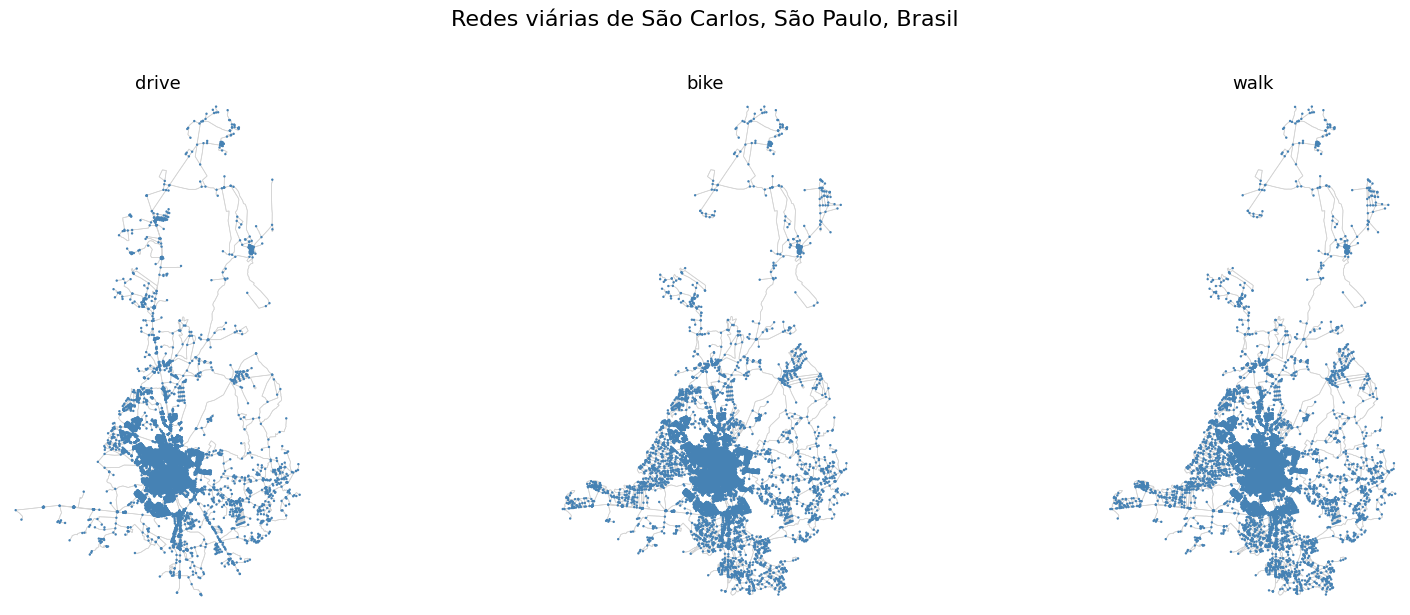

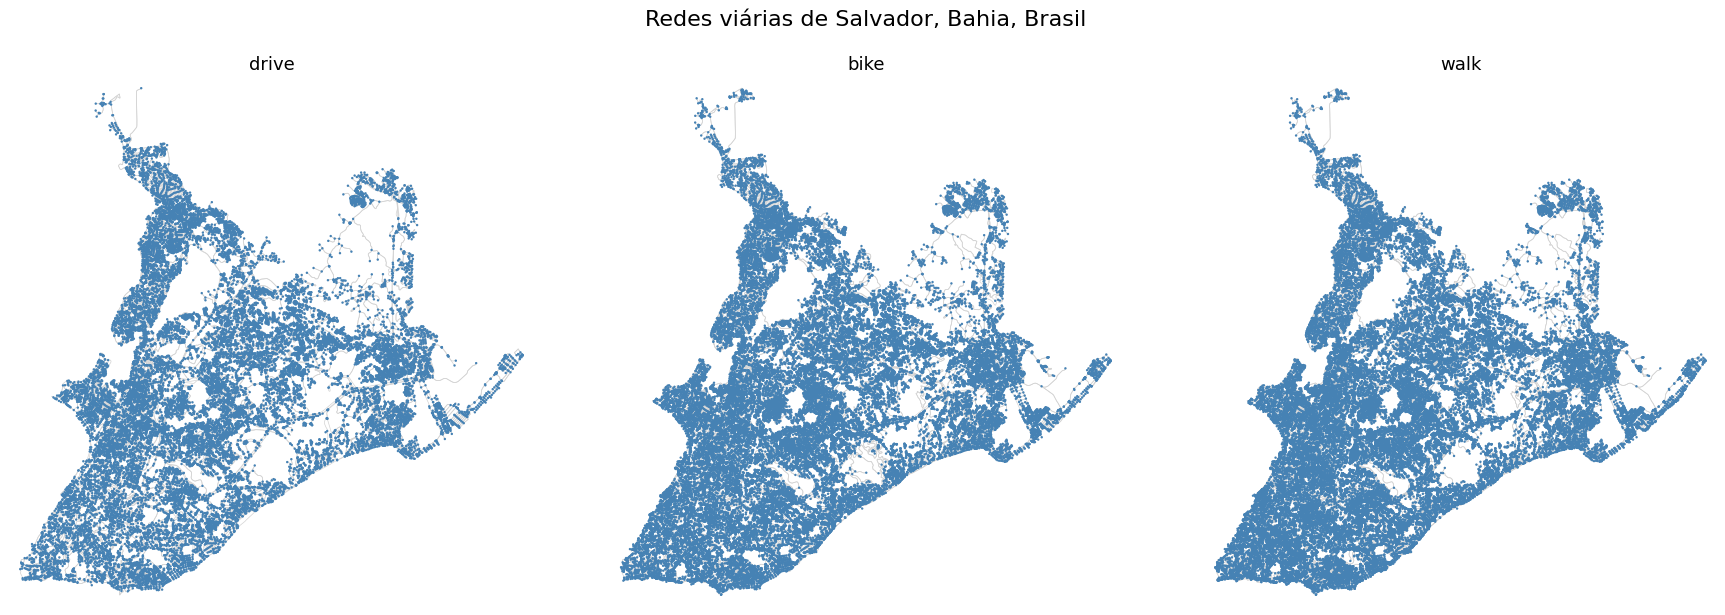

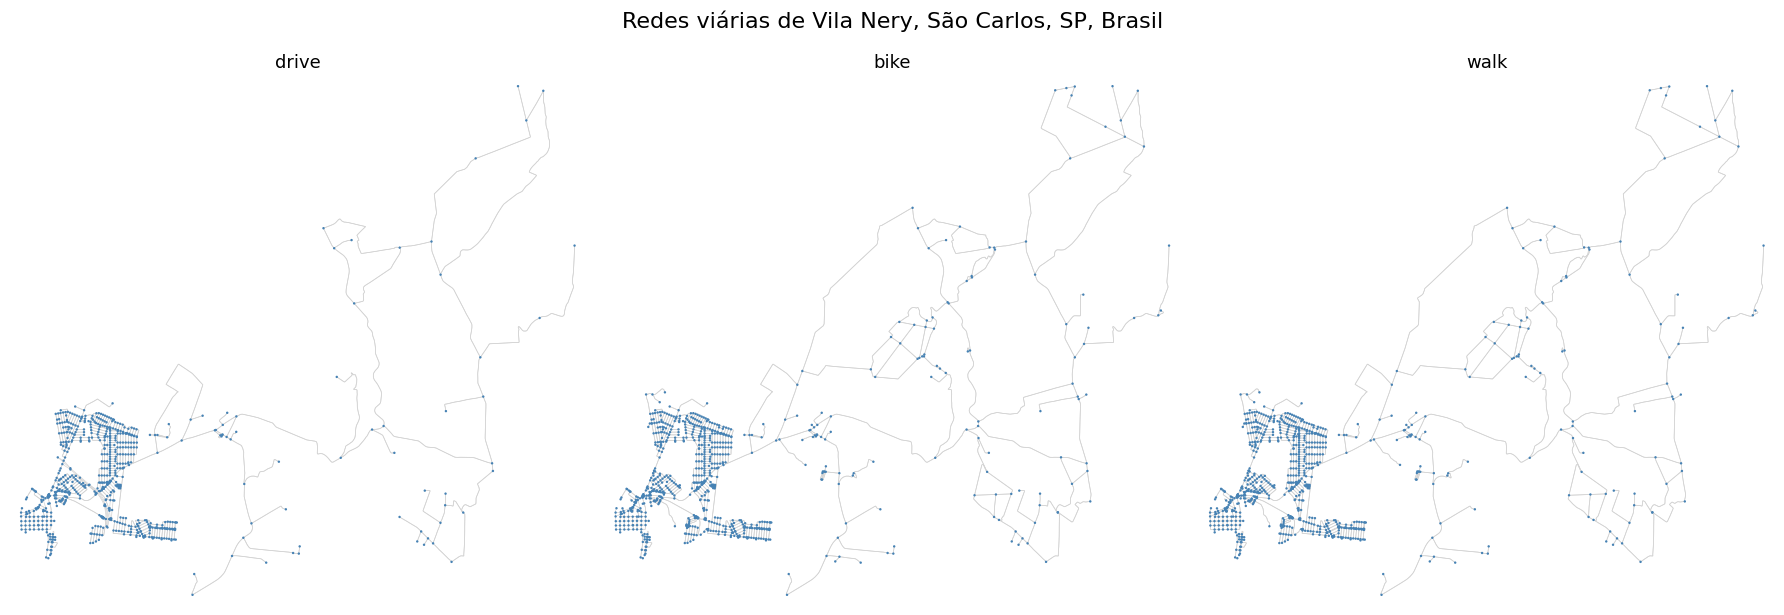

In [6]:
for lugar in lugares:
    fig, axes = plt.subplots(1, len(tipos), figsize=(18, 6))
    if len(tipos) == 1:
        axes = [axes]

    for ax, tipo in zip(axes, tipos):
        G_osm = G_osm_place_and_type[lugar][tipo]
        ox.plot_graph(G_osm, ax=ax, node_size=3, node_color="steelblue",
                      edge_color="lightgray", edge_linewidth=0.5,
                      bgcolor="white", show=False, close=False)
        ax.set_title(tipo, fontsize=13)

    fig.suptitle(f"Redes viárias de {lugar}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

### 5. Sequência e distribuição de grau

O **grau** de um nó $i$, denotado $k_i$, é o número de arestas incidentes a ele. No nosso caso, o número de trechos de rua que partem de um cruzamento.

A **sequência de graus** é o conjunto $\{k_1, k_2, \dots, k_N\}$ com um valor por nó.

A **distribuição de grau** $P(k)$ é a probabilidade de um nó escolhido ao acaso ter grau exatamente igual a $k$:

$$P(k) = \frac{n_k}{N}$$

em que $n_k$ é o número de nós com grau $k$ e $N$ é o número total de nós. Em redes viárias, é comum que $P(k)$ seja fortemente concentrada em poucos valores (3 e 4, tipicamente), pois cruzamentos costumam ter poucas ruas se encontrando, diferente de redes livres de escala como a internet, onde $P(k)$ tem cauda longa.

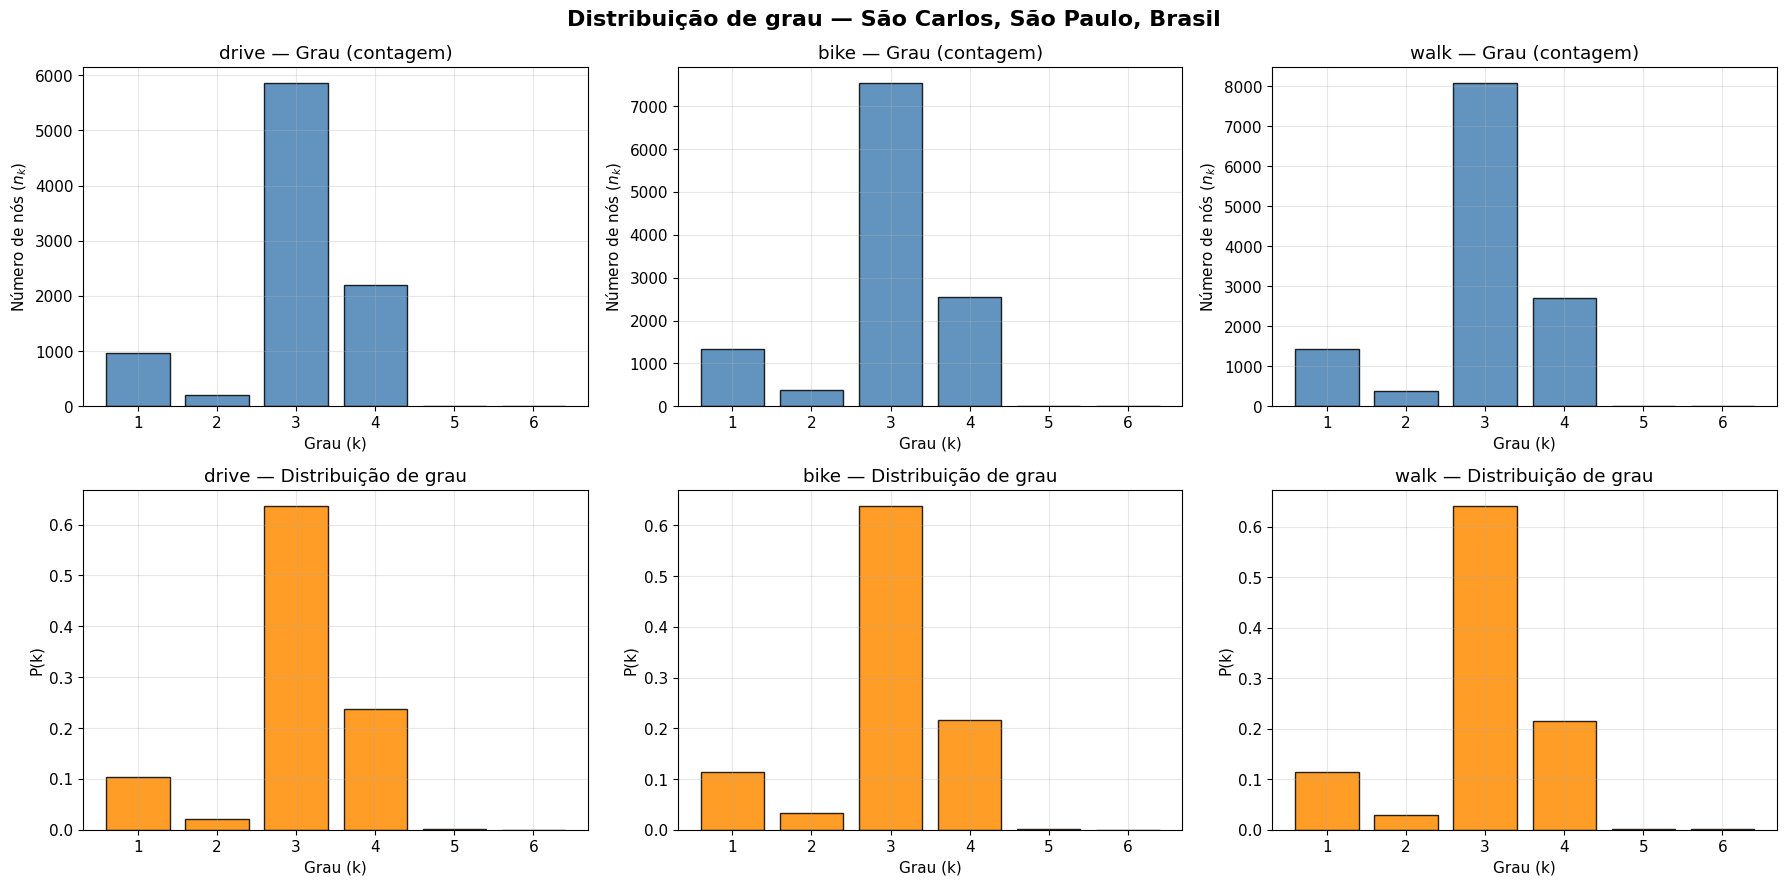

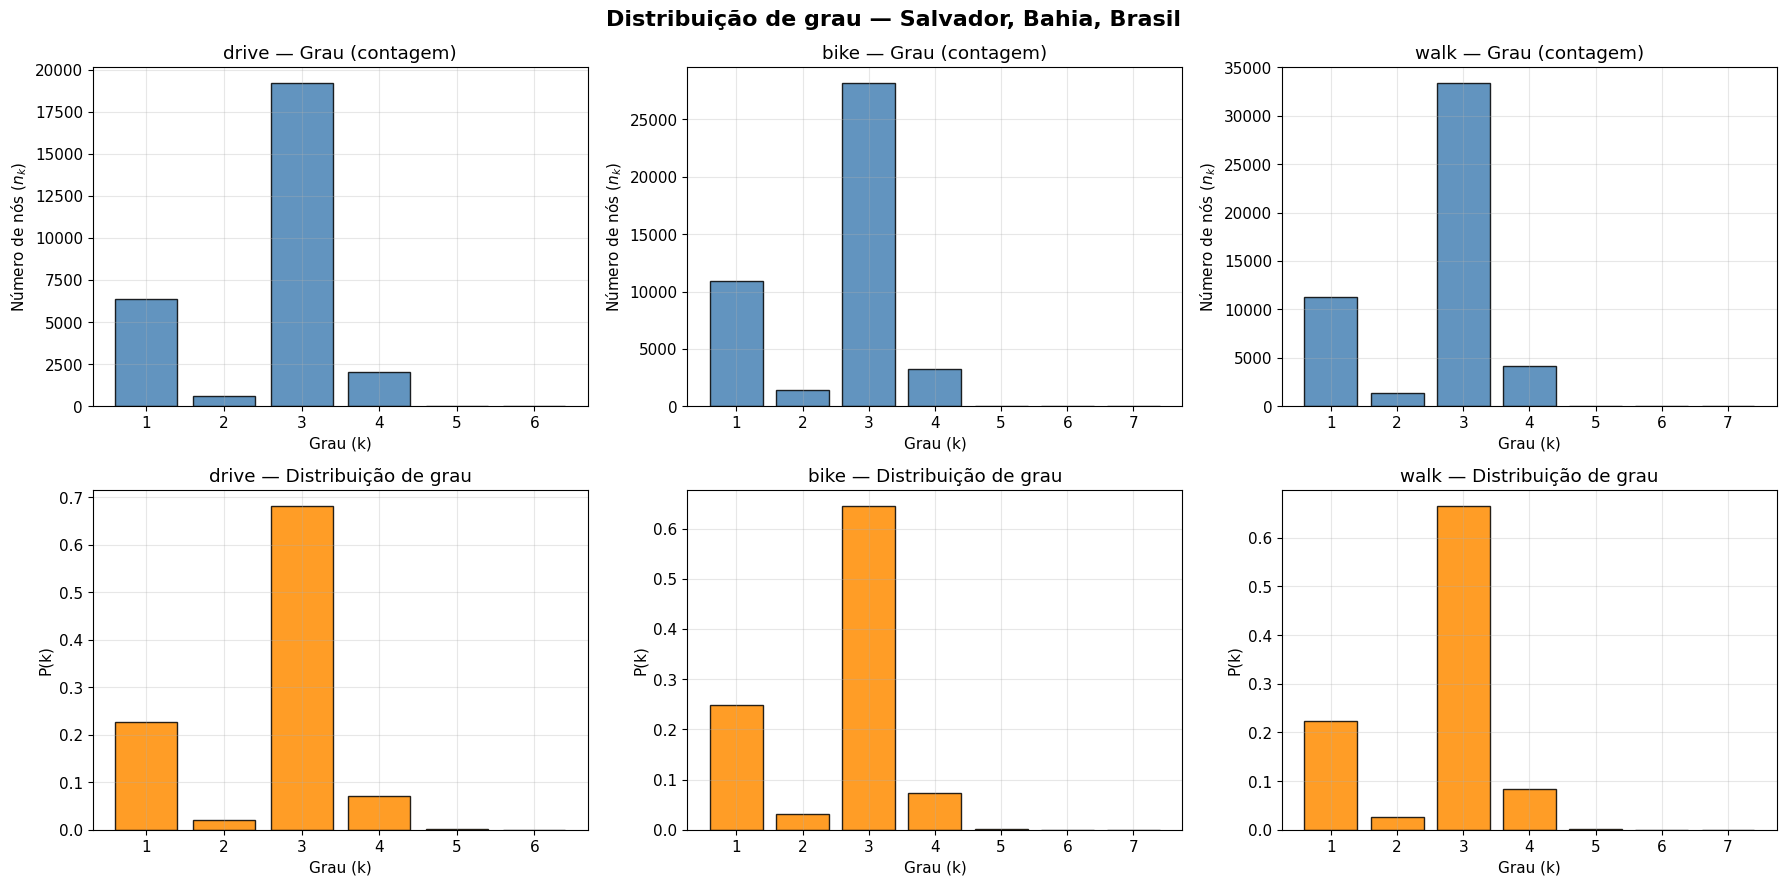

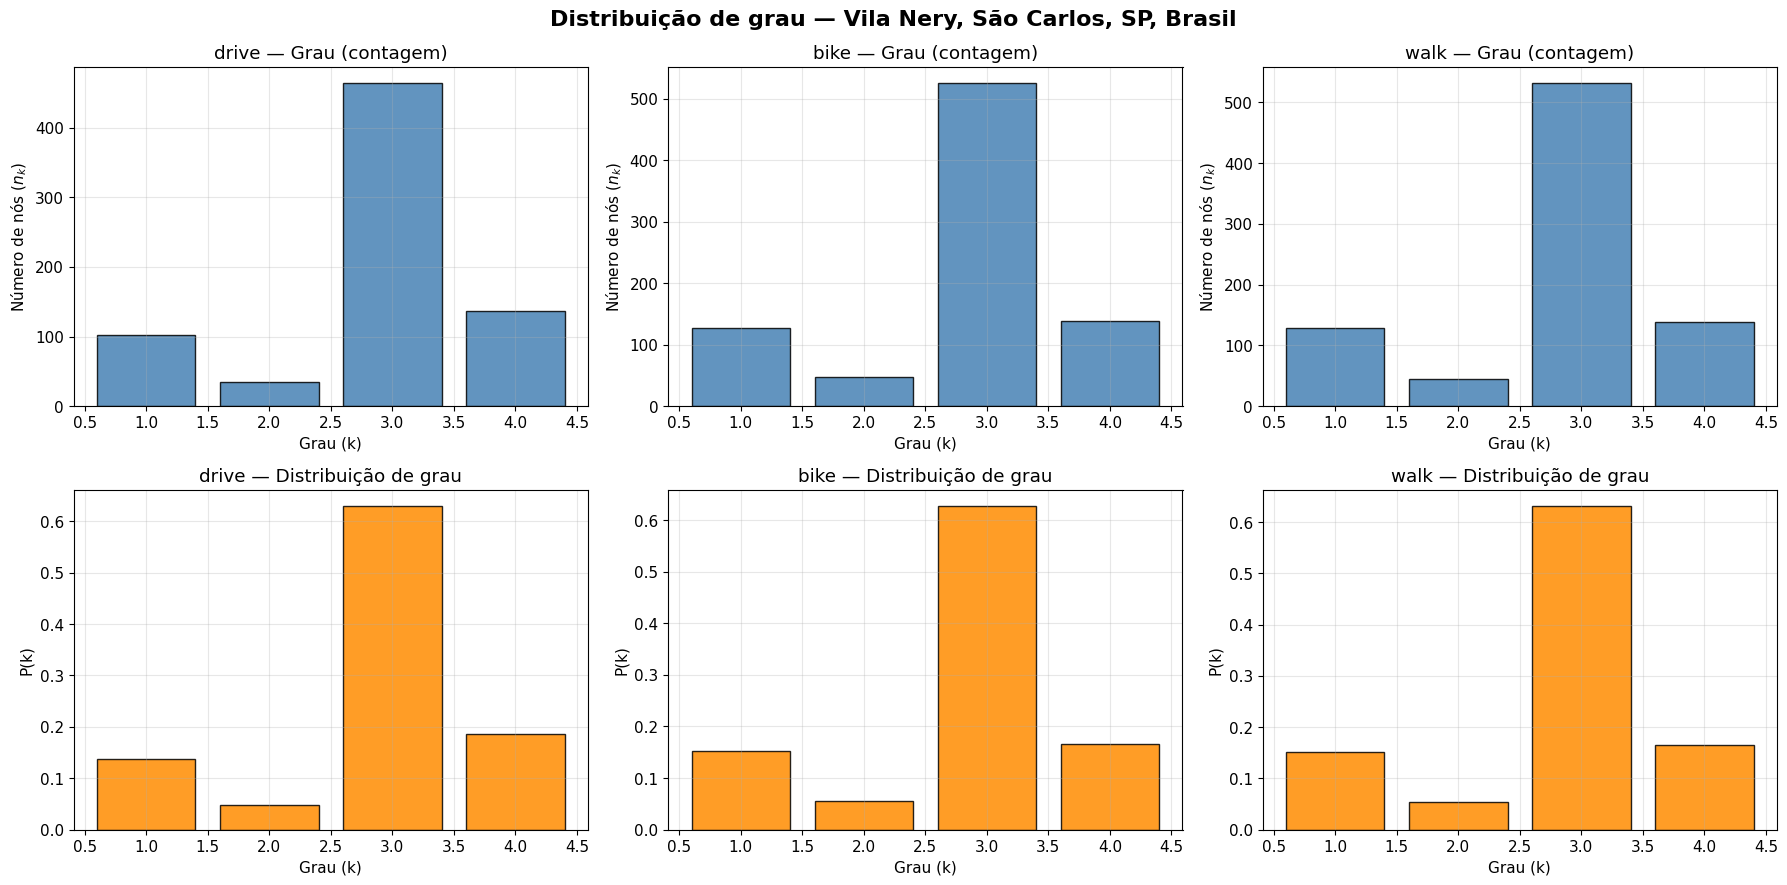

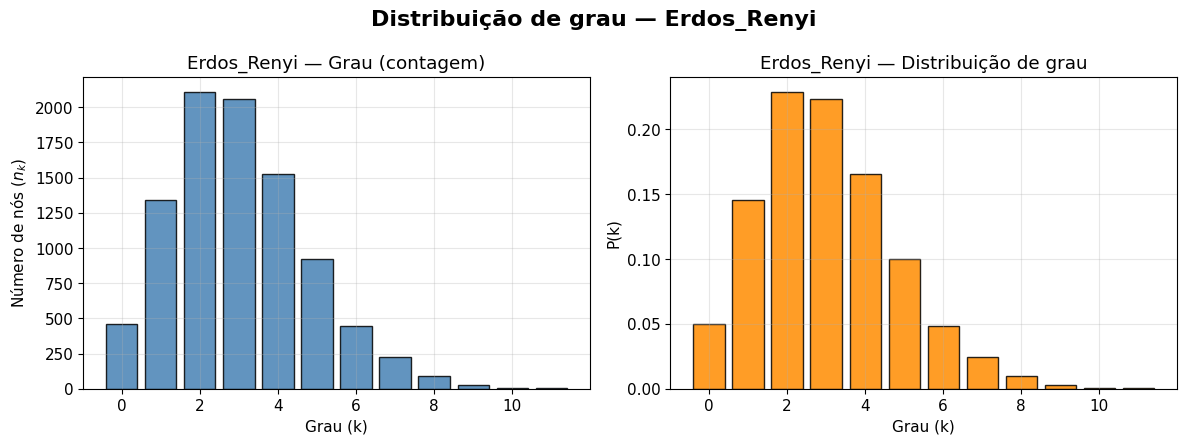

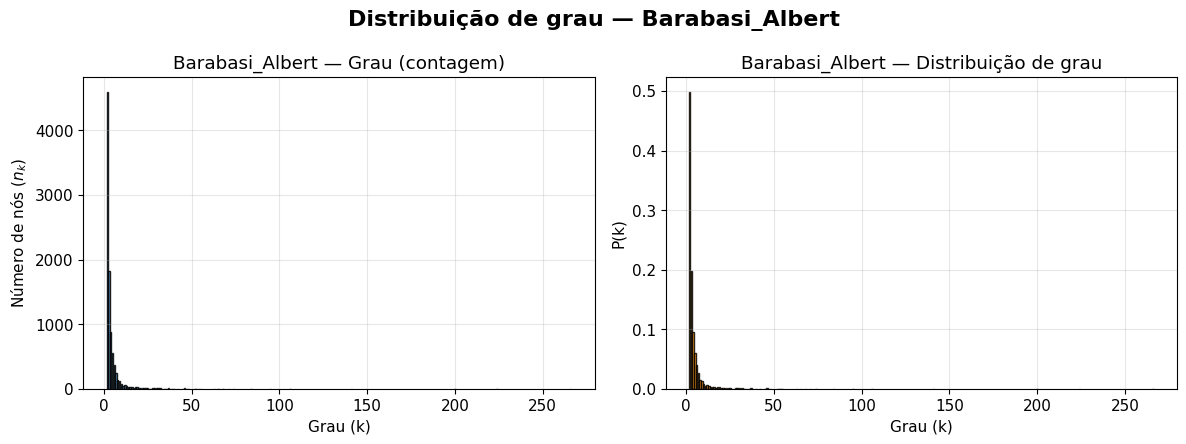

,lugar,tipo,grau_k,n_k,P_k
0,"São Carlos, São Paulo, Brasil",drive,1,956,0.1037
1,"São Carlos, São Paulo, Brasil",drive,2,196,0.0213
2,"São Carlos, São Paulo, Brasil",drive,3,5859,0.6356
3,"São Carlos, São Paulo, Brasil",drive,4,2197,0.2383
4,"São Carlos, São Paulo, Brasil",drive,5,9,0.0010
5,"São Carlos, São Paulo, Brasil",drive,6,1,0.0001
6,"São Carlos, São Paulo, Brasil",bike,1,1345,0.1136
7,"São Carlos, São Paulo, Brasil",bike,2,380,0.0321
8,"São Carlos, São Paulo, Brasil",bike,3,7544,0.6374
9,"São Carlos, São Paulo, Brasil",bike,4,2556,0.2160


In [7]:
df_dist_grau = pd.DataFrame(columns=["lugar", "tipo", "grau_k", "n_k", "P_k"])

def calcular_dist_grau(G, lugar, tipo, df):
    graus = np.array([grau for vertice, grau in G.degree()])
    valores_k, contagens = np.unique(graus, return_counts=True)
    P_k = contagens / contagens.sum()
    for k, n_k, p_k in zip(valores_k, contagens, P_k):
        df.loc[len(df)] = [lugar, tipo, k, n_k, p_k]
    return valores_k, contagens, P_k

# --- Parte 1: cidades/bairro, com o plot em grade original ---
for lugar in lugares:
    fig, axes = plt.subplots(2, len(tipos), figsize=(18, 9))
    if len(tipos) == 1:
        axes = np.array(axes).reshape(2, 1)

    for j, tipo in enumerate(tipos):
        G = preparar_grafo(G_osm_place_and_type[lugar][tipo])
        valores_k, contagens, P_k = calcular_dist_grau(G, lugar, tipo, df_dist_grau)

        axes[0, j].bar(valores_k, contagens, color="steelblue", edgecolor="black", alpha=0.85)
        axes[0, j].set_xlabel("Grau (k)")
        axes[0, j].set_ylabel("Número de nós ($n_k$)")
        axes[0, j].set_title(f"{tipo} — Grau (contagem)")

        axes[1, j].bar(valores_k, P_k, color="darkorange", edgecolor="black", alpha=0.85)
        axes[1, j].set_xlabel("Grau (k)")
        axes[1, j].set_ylabel("P(k)")
        axes[1, j].set_title(f"{tipo} — Distribuição de grau")

    fig.suptitle(f"Distribuição de grau — {lugar}", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

# --- Parte 2: grafos aleatórios, plot simples (1 gráfico por grafo, sem grade 2×len(tipos)) ---
for lugar in ["Erdos_Renyi", "Barabasi_Albert"]:
    tipo = "unique"
    G = preparar_grafo(G_osm_place_and_type[lugar][tipo])
    valores_k, contagens, P_k = calcular_dist_grau(G, lugar, tipo, df_dist_grau)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].bar(valores_k, contagens, color="steelblue", edgecolor="black", alpha=0.85)
    axes[0].set_xlabel("Grau (k)"); axes[0].set_ylabel("Número de nós ($n_k$)")
    axes[0].set_title(f"{lugar} — Grau (contagem)")

    axes[1].bar(valores_k, P_k, color="darkorange", edgecolor="black", alpha=0.85)
    axes[1].set_xlabel("Grau (k)"); axes[1].set_ylabel("P(k)")
    axes[1].set_title(f"{lugar} — Distribuição de grau")

    fig.suptitle(f"Distribuição de grau — {lugar}", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

display(df_dist_grau.style.format({"grau_k": "{:.0f}", "n_k": "{:.0f}", "P_k": "{:.4f}"}))

### 6. Primeiro, segundo e terceiro momentos do grau

O **grau médio** $\langle k \rangle$ é o primeiro momento da distribuição de grau:

$$\langle k \rangle = \frac{1}{N}\sum_{i=1}^{N} k_i = \sum_k k \, P(k)$$

Para um grafo simples não-direcionado, existe ainda uma relação exata com o número de arestas $E$:

$$\langle k \rangle = \frac{2E}{N}$$

pois cada aresta contribui com $+1$ para o grau de **dois** nós. 

Ou seja, neste caso, "grau_medio_2E" = "m1"

Os **momentos estatísticos** generalizam a ideia de grau médio. O momento de ordem $n$ é definido como:

$$\langle k^n \rangle = \frac{1}{N}\sum_{i=1}^N k_i^n = \sum_k k^n P(k)$$

- O **segundo momento** $\langle k^2 \rangle$ mede a dispersão dos graus ao redor de zero, sendo usado no cálculo da variância.
- O **terceiro momento** $\langle k^3 \rangle$ captura a **assimetria (skewness)** da distribuição: distribuições com cauda longa à direita (poucos nós com grau muito alto, os "hubs") têm $\langle k^3 \rangle$ desproporcionalmente grande.


In [8]:
df_basico['m1'] = np.nan
df_basico['m2'] = np.nan
df_basico['m3'] = np.nan

for lugar, tipo in combinacoes:

    G_osm = G_osm_place_and_type[lugar][tipo]
    G = preparar_grafo(G_osm)

    graus = np.array([grau for vertice, grau in G.degree()])

    m1 = graus.mean()
    m2 = np.mean(graus**2)
    m3 = np.mean(graus**3)

    df_basico.loc[
        (df_basico["lugar"] == lugar) &
        (df_basico["tipo"] == tipo),
        ['m1', 'm2', 'm3']
    ] = [m1, m2, m3]

display(
    df_basico.style.format({
        "nos_bruto": "{:.0f}",
        "arestas_bruto": "{:.0f}",
        "nos": "{:.0f}",
        "arestas": "{:.0f}",
        "grau_medio_2E": "{:.3f}",
        "m1": "{:.3f}",
        "m2": "{:.3f}",
        "m3": "{:.3f}"
    }) 
)

,lugar,tipo,nos_bruto,arestas_bruto,nos,arestas,grau_medio_2E,m1,m2,m3
0,"São Carlos, São Paulo, Brasil",drive,9218,22638,9218,13882,3.012,3.012,9.751,32.834
1,"São Carlos, São Paulo, Brasil",bike,11836,29964,11836,17509,2.959,2.959,9.459,31.532
2,"São Carlos, São Paulo, Brasil",walk,12644,37926,12644,18719,2.961,2.961,9.475,31.622
3,"Salvador, Bahia, Brasil",drive,28215,64717,28215,36680,2.600,2.600,7.600,23.447
4,"Salvador, Bahia, Brasil",bike,43752,99319,43752,55699,2.546,2.546,7.385,22.780
5,"Salvador, Bahia, Brasil",walk,50231,133176,50231,65561,2.610,2.610,7.677,23.886
6,"Vila Nery, São Carlos, SP, Brasil",drive,738,1835,738,1056,2.862,2.862,8.957,29.374
7,"Vila Nery, São Carlos, SP, Brasil",bike,840,2107,840,1178,2.805,2.805,8.660,28.098
8,"Vila Nery, São Carlos, SP, Brasil",walk,844,2394,844,1185,2.808,2.808,8.673,28.137
9,Erdos_Renyi,unique,9218,13882,9218,13882,3.012,3.012,12.131,58.238


### 7. Variância, desvio padrão e coeficiente de variação do grau

A **variância do grau** mede o quanto os graus se dispersam em torno da média:

$$\sigma_k^2 = \langle k^2 \rangle - \langle k \rangle^2 = \frac{1}{N}\sum_{i=1}^N (k_i - \langle k \rangle)^2$$

O **desvio padrão** é $\sigma_k = \sqrt{\sigma_k^2}$, na mesma unidade do grau (mais interpretável que a variância).

Quanto maior $\sigma_k$, mais **heterogênea** é a rede em termos de conectividade local.


In [9]:
df_basico['var_k'] = np.nan
df_basico['std_k'] = np.nan
df_basico['cv_k'] = np.nan


for lugar, tipo in combinacoes:

    G_osm = G_osm_place_and_type[lugar][tipo]
    G = preparar_grafo(G_osm)

    graus = np.array([grau for vertice, grau in G.degree()])

    var_k = np.var(graus)    # equivalente a m2 - m1**2
    std_k = np.std(graus)
    cv_k = std_k / df_basico.loc[(df_basico["lugar"] == lugar) & (df_basico["tipo"] == tipo), 'm1'].iloc[0]  
    # .loc[LINHAS, COLUNAS] retorna uma Series de valores da coluna "m1" (cuja coluna "lugar" == lugar AND "tipo" == tipo)
    # Por isso, usa-se .iloc[0] para pegar o primeiro elemento da Series (Pois estamos trabalhando com correspondencias únicas, então a Series terá por natureza apenas um iterando)

    df_basico.loc[
        (df_basico["lugar"] == lugar) &
        (df_basico["tipo"] == tipo),
        ['var_k', 'std_k', 'cv_k']
    ] = [var_k, std_k, cv_k]

display(
    df_basico.style.format({
        "nos_bruto": "{:.0f}",
        "arestas_bruto": "{:.0f}",
        "nos": "{:.0f}",
        "arestas": "{:.0f}",
        "grau_medio_2E": "{:.3f}",
        "m1": "{:.3f}",
        "m2": "{:.3f}",
        "m3": "{:.3f}",
        "var_k": "{:.3f}",
        "std_k": "{:.3f}",
        "cv_k": "{:.4f}"
    }) 
)

,lugar,tipo,nos_bruto,arestas_bruto,nos,arestas,grau_medio_2E,m1,m2,m3,var_k,std_k,cv_k
0,"São Carlos, São Paulo, Brasil",drive,9218,22638,9218,13882,3.012,3.012,9.751,32.834,0.679,0.824,0.2736
1,"São Carlos, São Paulo, Brasil",bike,11836,29964,11836,17509,2.959,2.959,9.459,31.532,0.705,0.840,0.2839
2,"São Carlos, São Paulo, Brasil",walk,12644,37926,12644,18719,2.961,2.961,9.475,31.622,0.707,0.841,0.2841
3,"Salvador, Bahia, Brasil",drive,28215,64717,28215,36680,2.600,2.600,7.600,23.447,0.839,0.916,0.3524
4,"Salvador, Bahia, Brasil",bike,43752,99319,43752,55699,2.546,2.546,7.385,22.780,0.902,0.950,0.3731
5,"Salvador, Bahia, Brasil",walk,50231,133176,50231,65561,2.610,2.610,7.677,23.886,0.863,0.929,0.3558
6,"Vila Nery, São Carlos, SP, Brasil",drive,738,1835,738,1056,2.862,2.862,8.957,29.374,0.767,0.876,0.3060
7,"Vila Nery, São Carlos, SP, Brasil",bike,840,2107,840,1178,2.805,2.805,8.660,28.098,0.793,0.890,0.3175
8,"Vila Nery, São Carlos, SP, Brasil",walk,844,2394,844,1185,2.808,2.808,8.673,28.137,0.788,0.888,0.3161
9,Erdos_Renyi,unique,9218,13882,9218,13882,3.012,3.012,12.131,58.238,3.060,1.749,0.5807


### 8. Entropia do grau

A **entropia de Shannon** aplicada à distribuição de grau mede o grau de "incerteza" ou "diversidade" da distribuição $P(k)$:

$$H(K) = -\sum_k P(k)\, \log_2 P(k)$$

- $H$ é **máxima** quando os graus estão uniformemente distribuídos entre todos os valores possíveis (máxima incerteza sobre o grau de um nó sorteado ao acaso).
- $H$ é **mínima** ($H=0$) quando todos os nós têm exatamente o mesmo grau (rede regular).

Costuma-se também reportar a **entropia normalizada** $H/\log_2(k_{max}-k_{min}+1)$, que varia entre 0 e 1, facilitando comparações entre redes.

In [10]:
df_basico['Entropia_H(K)'] = np.nan
df_basico['H_max_possivel'] = np.nan
df_basico['H_norm'] = np.nan

for lugar, tipo in combinacoes:

    G_osm = G_osm_place_and_type[lugar][tipo]
    G = preparar_grafo(G_osm)

    P_k = df_dist_grau.loc[(df_dist_grau["lugar"] == lugar) &(df_dist_grau["tipo"] == tipo), "P_k"]
    # Neste dataframe, há linhas que se repetem com o mesmo 'lugar' e 'tipo', pois são diferenciadas pelo 'grau_k'.
    # Dessa forma, .loc retornará uma Series de valores de P_k

    H = -np.sum(P_k * np.log2(P_k))
    n_valores_possiveis = graus.max() - graus.min() + 1
    H_max = np.log2(n_valores_possiveis)
    H_norm = H / H_max

    df_basico.loc[
        (df_basico["lugar"] == lugar) &
        (df_basico["tipo"] == tipo),
        ['Entropia_H(K)', 'H_max_possivel', 'H_norm']
    ] = [H, H_max, H_norm]

display(
    df_basico.style.format({
        "nos_bruto": "{:.0f}",
        "arestas_bruto": "{:.0f}",
        "nos": "{:.0f}",
        "arestas": "{:.0f}",
        "grau_medio_2E": "{:.3f}",
        "m1": "{:.3f}",
        "m2": "{:.3f}",
        "m3": "{:.3f}",
        "var_k": "{:.3f}",
        "std_k": "{:.3f}",
        "cv_k": "{:.4f}",
        "Entropia_H(K)": "{:.4f}",
        "H_max_possivel": "{:.4f}",
         "H_norm": "{:.4f}"
    }) 
)

,lugar,tipo,nos_bruto,arestas_bruto,nos,arestas,grau_medio_2E,m1,m2,m3,var_k,std_k,cv_k,Entropia_H(K),H_max_possivel,H_norm
0,"São Carlos, São Paulo, Brasil",drive,9218,22638,9218,13882,3.012,3.012,9.751,32.834,0.679,0.824,0.2736,1.3770,8.0498,0.1711
1,"São Carlos, São Paulo, Brasil",bike,11836,29964,11836,17509,2.959,2.959,9.459,31.532,0.705,0.840,0.2839,1.4175,8.0498,0.1761
2,"São Carlos, São Paulo, Brasil",walk,12644,37926,12644,18719,2.961,2.961,9.475,31.622,0.707,0.841,0.2841,1.4140,8.0498,0.1757
3,"Salvador, Bahia, Brasil",drive,28215,64717,28215,36680,2.600,2.600,7.600,23.447,0.839,0.916,0.3524,1.2617,8.0498,0.1567
4,"Salvador, Bahia, Brasil",bike,43752,99319,43752,55699,2.546,2.546,7.385,22.780,0.902,0.950,0.3731,1.3554,8.0498,0.1684
5,"Salvador, Bahia, Brasil",walk,50231,133176,50231,65561,2.610,2.610,7.677,23.886,0.863,0.929,0.3558,1.3287,8.0498,0.1651
6,"Vila Nery, São Carlos, SP, Brasil",drive,738,1835,738,1056,2.862,2.862,8.957,29.374,0.767,0.876,0.3060,1.4751,8.0498,0.1832
7,"Vila Nery, São Carlos, SP, Brasil",bike,840,2107,840,1178,2.805,2.805,8.660,28.098,0.793,0.890,0.3175,1.4987,8.0498,0.1862
8,"Vila Nery, São Carlos, SP, Brasil",walk,844,2394,844,1185,2.808,2.808,8.673,28.137,0.788,0.888,0.3161,1.4864,8.0498,0.1847
9,Erdos_Renyi,unique,9218,13882,9218,13882,3.012,3.012,12.131,58.238,3.060,1.749,0.5807,2.7958,8.0498,0.3473


### 9. Grau máximo e mínimo

Medidas simples, mas informativas sobre os extremos da rede:

- $k_{max}$: grau do nó mais conectado (o "hub" local da rede, se existir)
- $k_{min}$: grau do nó menos conectado

Em uma rede viária conexa e sem nós desconectados, espera-se $k_{min} \geq 1$.

depende inteiramente de geografia (G.nodes[n]["x"], G.nodes[n]["y"], ox.plot_graph), então não faz sentido — e nem é fisicamente possível — rodá-la para os grafos aleatórios

------------------------ Rede tipo drive em São Carlos, São Paulo, Brasil  -------------------------
Grau máximo k_max: 6  (nº de nós com esse grau: 1)
Grau mínimo k_min: 1  (nº de nós com esse grau: 956)

------------------------- Rede tipo bike em São Carlos, São Paulo, Brasil  -------------------------
Grau máximo k_max: 6  (nº de nós com esse grau: 2)
Grau mínimo k_min: 1  (nº de nós com esse grau: 1345)

------------------------- Rede tipo walk em São Carlos, São Paulo, Brasil  -------------------------
Grau máximo k_max: 6  (nº de nós com esse grau: 6)
Grau mínimo k_min: 1  (nº de nós com esse grau: 1439)



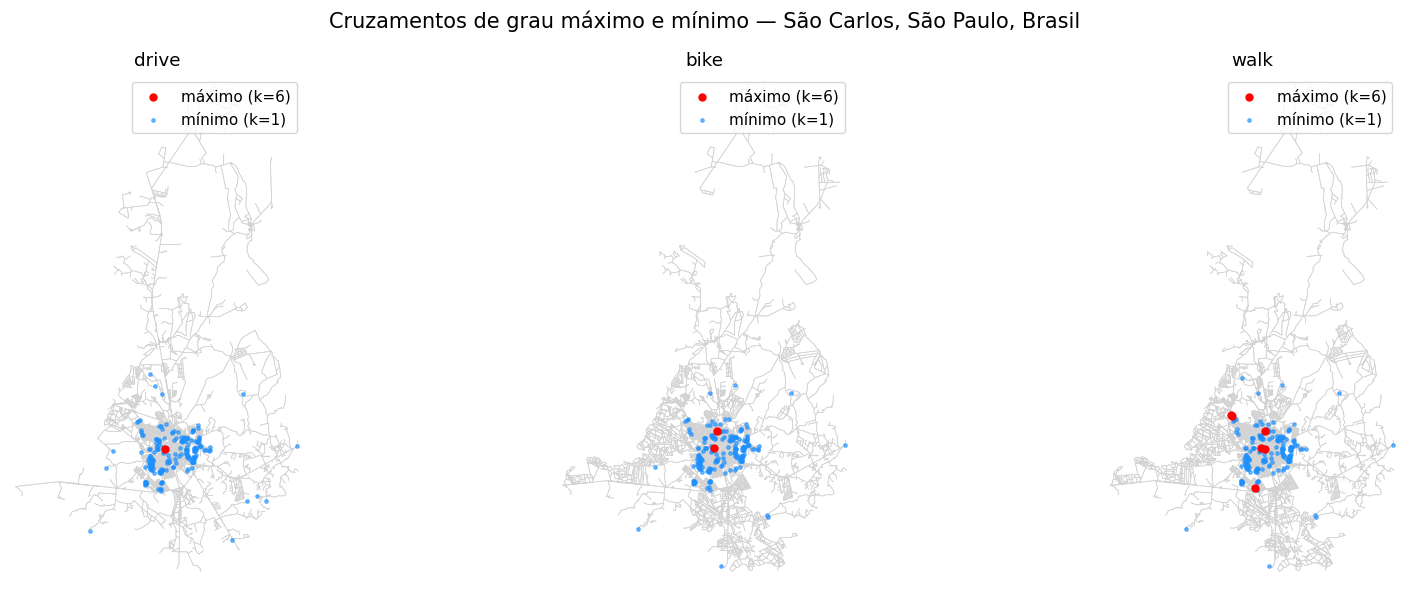

--------------------------- Rede tipo drive em Salvador, Bahia, Brasil  ----------------------------
Grau máximo k_max: 6  (nº de nós com esse grau: 1)
Grau mínimo k_min: 1  (nº de nós com esse grau: 6371)

---------------------------- Rede tipo bike em Salvador, Bahia, Brasil  ----------------------------
Grau máximo k_max: 7  (nº de nós com esse grau: 1)
Grau mínimo k_min: 1  (nº de nós com esse grau: 10910)

---------------------------- Rede tipo walk em Salvador, Bahia, Brasil  ----------------------------
Grau máximo k_max: 7  (nº de nós com esse grau: 1)
Grau mínimo k_min: 1  (nº de nós com esse grau: 11274)



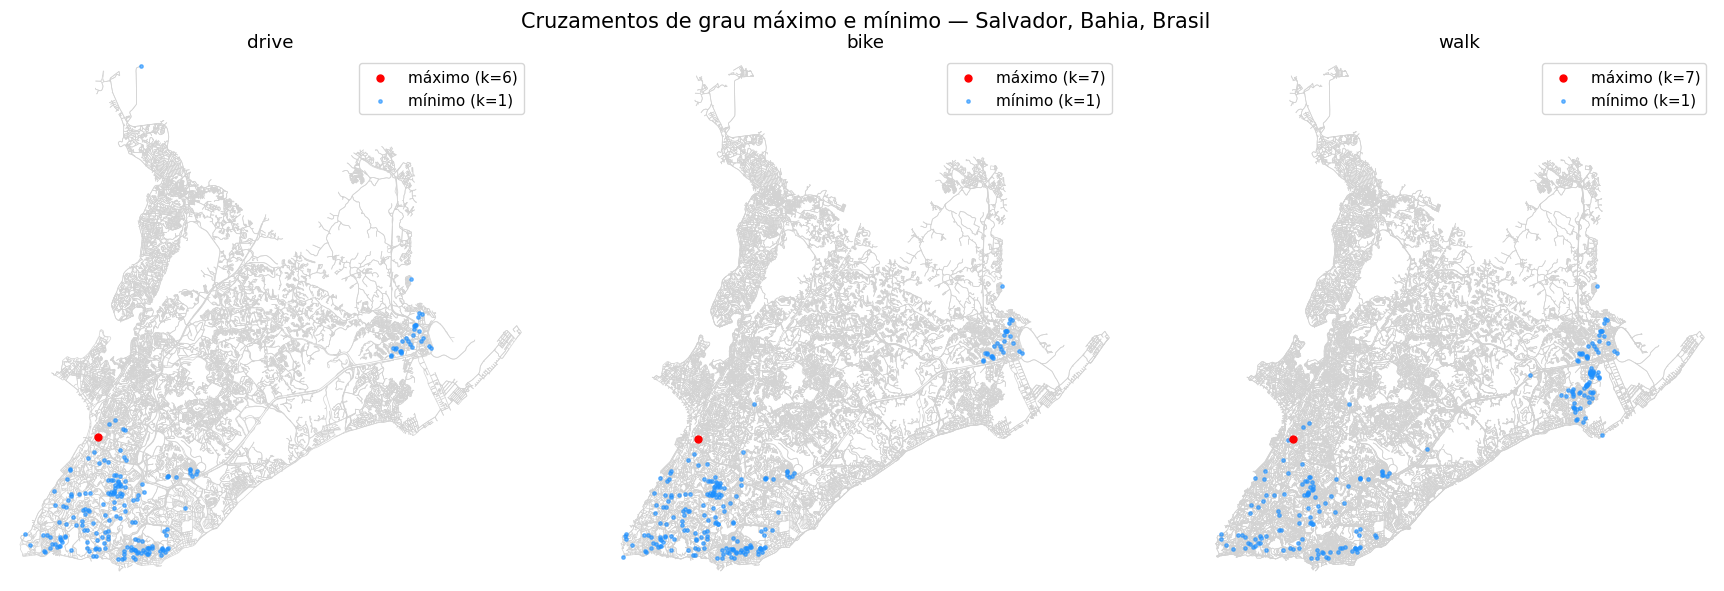

---------------------- Rede tipo drive em Vila Nery, São Carlos, SP, Brasil  -----------------------
Grau máximo k_max: 4  (nº de nós com esse grau: 137)
Grau mínimo k_min: 1  (nº de nós com esse grau: 102)

----------------------- Rede tipo bike em Vila Nery, São Carlos, SP, Brasil  -----------------------
Grau máximo k_max: 4  (nº de nós com esse grau: 139)
Grau mínimo k_min: 1  (nº de nós com esse grau: 128)

----------------------- Rede tipo walk em Vila Nery, São Carlos, SP, Brasil  -----------------------
Grau máximo k_max: 4  (nº de nós com esse grau: 139)
Grau mínimo k_min: 1  (nº de nós com esse grau: 128)



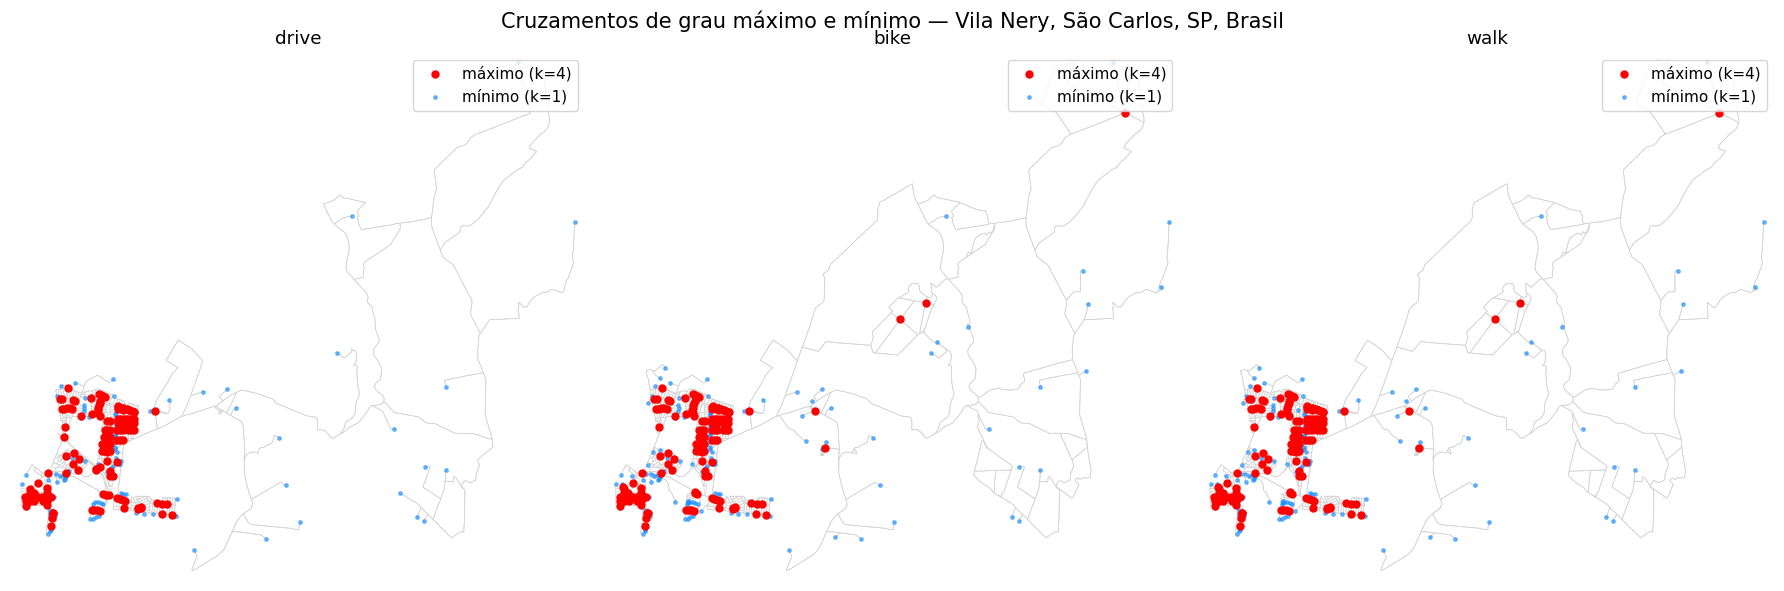

In [11]:
for lugar in lugares:
    fig, axes = plt.subplots(1, len(tipos),figsize=(18, 6))
    for i, tipo in enumerate(tipos):

        G_osm = G_osm_place_and_type[lugar][tipo]
        G = preparar_grafo(G_osm)

        graus = np.array([grau for vertice, grau in G.degree()])

        k_max = graus.max()
        k_min = graus.min()

        nos_k_max = [n for n, k in G.degree() if k == k_max]
        nos_k_min = [n for n, k in G.degree() if k == k_min]

        print(f" Rede tipo {tipo} em {lugar}  ".center(100, "-"))
        print(f"Grau máximo k_max: {k_max}  (nº de nós com esse grau: {len(nos_k_max)})")
        print(f"Grau mínimo k_min: {k_min}  (nº de nós com esse grau: {len(nos_k_min)})\n")

        # Plot da rede
        fig_temp, ax_temp = ox.plot_graph(G_osm,node_size=0,edge_color="lightgray",edge_linewidth=0.5,bgcolor="white",show=False,close=False)
     
        plt.close(fig_temp)
        
        xs_max = [G.nodes[n]["x"] for n in nos_k_max]
        ys_max = [G.nodes[n]["y"] for n in nos_k_max]
        
        nos_k_min_plot = nos_k_min[:200]
        
        xs_min = [G.nodes[n]["x"] for n in nos_k_min_plot]
        ys_min = [G.nodes[n]["y"] for n in nos_k_min_plot]
        
        # Plot diretamente no subplot
        ox.plot_graph(G_osm,ax=axes[i],node_size=0,edge_color="lightgray",edge_linewidth=0.5,bgcolor="white",show=False,close=False)
        
        axes[i].scatter(xs_max,ys_max,c="red",s=25,label=f"máximo (k={k_max})",zorder=5)
        axes[i].scatter(xs_min,ys_min,c="dodgerblue",s=6,alpha=0.6,label=f"mínimo (k={k_min})",zorder=4)
        axes[i].set_title(tipo)
        axes[i].legend(loc="upper right")
        
    # Título geral da cidade
    fig.suptitle(f"Cruzamentos de grau máximo e mínimo — {lugar}",fontsize=15)
        
    plt.tight_layout()
    plt.show()
        

### 11. Boxplot do grau: Quantis e IQR

Os **quantis** dividem a distribuição de grau em partes com a mesma proporção de observações. Os mais usados são os **quartis**:

- $Q_1$ (25º percentil): 25% dos nós têm grau $\leq Q_1$
- $Q_2$ (mediana, 50º percentil)
- $Q_3$ (75º percentil): 75% dos nós têm grau $\leq Q_3$

O **intervalo interquartil (IQR)** é uma medida robusta de dispersão (pouco sensível a outliers):

$$IQR = Q_3 - Q_1$$

O **boxplot** (diagrama de caixa) resume visualmente mediana, quartis, IQR e outliers em uma única figura

------------------------ Rede tipo drive em São Carlos, São Paulo, Brasil  -------------------------
Q1 (25%): 3.00                      Q2 (mediana): 3.00                      Q3 (75%): 3.00
Limites de outlier (Tukey): [3.00, 3.00]         -         IQR: 0.00
Nº de nós outliers pelo critério de Tukey: 3359 (36.44% da rede)

------------------------- Rede tipo bike em São Carlos, São Paulo, Brasil  -------------------------
Q1 (25%): 3.00                      Q2 (mediana): 3.00                      Q3 (75%): 3.00
Limites de outlier (Tukey): [3.00, 3.00]         -         IQR: 0.00
Nº de nós outliers pelo critério de Tukey: 4292 (36.26% da rede)

------------------------- Rede tipo walk em São Carlos, São Paulo, Brasil  -------------------------
Q1 (25%): 3.00                      Q2 (mediana): 3.00                      Q3 (75%): 3.00
Limites de outlier (Tukey): [3.00, 3.00]         -         IQR: 0.00
Nº de nós outliers pelo critério de Tukey: 4557 (36.04% da rede)



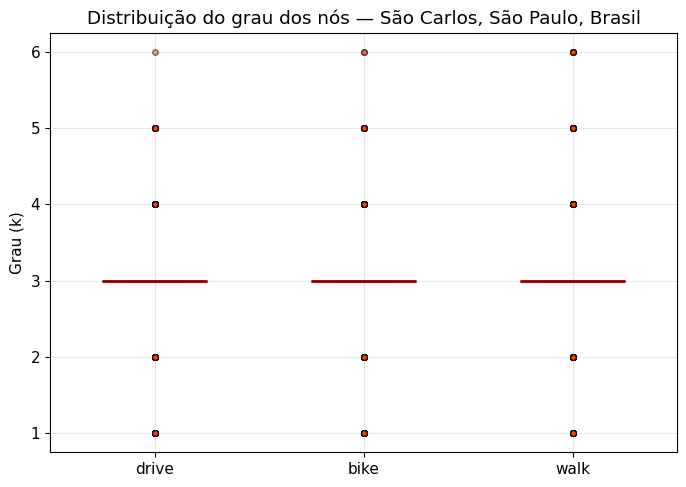

--------------------------- Rede tipo drive em Salvador, Bahia, Brasil  ----------------------------
Q1 (25%): 3.00                      Q2 (mediana): 3.00                      Q3 (75%): 3.00
Limites de outlier (Tukey): [3.00, 3.00]         -         IQR: 0.00
Nº de nós outliers pelo critério de Tukey: 9012 (31.94% da rede)

---------------------------- Rede tipo bike em Salvador, Bahia, Brasil  ----------------------------
Q1 (25%): 2.00                      Q2 (mediana): 3.00                      Q3 (75%): 3.00
Limites de outlier (Tukey): [0.50, 4.50]         -         IQR: 1.00
Nº de nós outliers pelo critério de Tukey: 52 (0.12% da rede)

---------------------------- Rede tipo walk em Salvador, Bahia, Brasil  ----------------------------
Q1 (25%): 2.00                      Q2 (mediana): 3.00                      Q3 (75%): 3.00
Limites de outlier (Tukey): [0.50, 4.50]         -         IQR: 1.00
Nº de nós outliers pelo critério de Tukey: 79 (0.16% da rede)



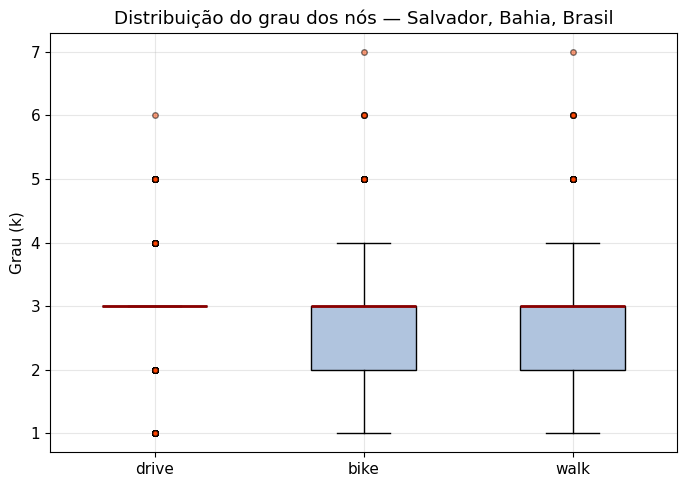

---------------------- Rede tipo drive em Vila Nery, São Carlos, SP, Brasil  -----------------------
Q1 (25%): 3.00                      Q2 (mediana): 3.00                      Q3 (75%): 3.00
Limites de outlier (Tukey): [3.00, 3.00]         -         IQR: 0.00
Nº de nós outliers pelo critério de Tukey: 274 (37.13% da rede)

----------------------- Rede tipo bike em Vila Nery, São Carlos, SP, Brasil  -----------------------
Q1 (25%): 3.00                      Q2 (mediana): 3.00                      Q3 (75%): 3.00
Limites de outlier (Tukey): [3.00, 3.00]         -         IQR: 0.00
Nº de nós outliers pelo critério de Tukey: 314 (37.38% da rede)

----------------------- Rede tipo walk em Vila Nery, São Carlos, SP, Brasil  -----------------------
Q1 (25%): 3.00                      Q2 (mediana): 3.00                      Q3 (75%): 3.00
Limites de outlier (Tukey): [3.00, 3.00]         -         IQR: 0.00
Nº de nós outliers pelo critério de Tukey: 312 (36.97% da rede)



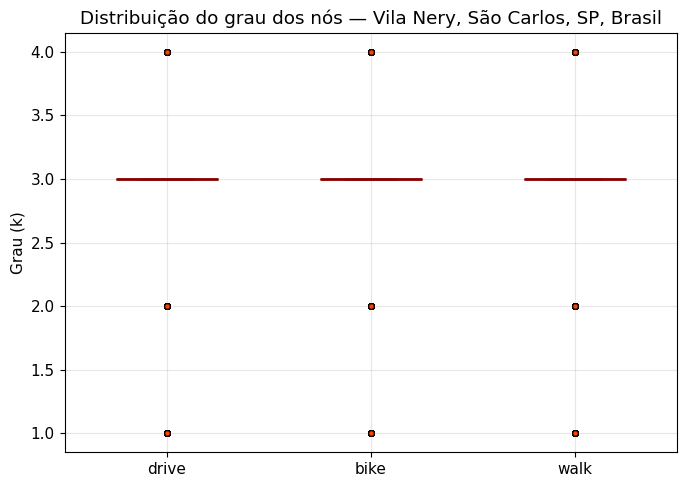

------------------------------------------- Erdos_Renyi --------------------------------------------
Q1: 2.00  Mediana: 3.00  Q3: 4.00  IQR: 2.00
Outliers (Tukey): 128 (1.39%)

----------------------------------------- Barabasi_Albert ------------------------------------------
Q1: 2.00  Mediana: 3.00  Q3: 4.00  IQR: 2.00
Outliers (Tukey): 753 (8.17%)



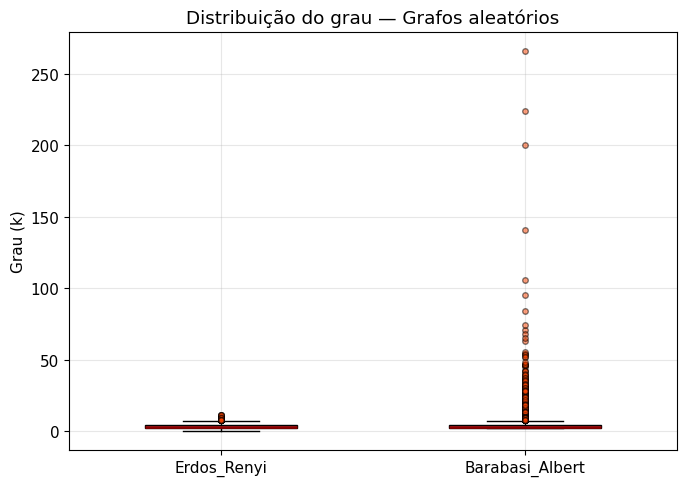

In [12]:
for lugar in lugares:
    fig, ax = plt.subplots(figsize=(7, 5))

    dados = []
    labels = []

    for tipo in tipos:
        G_osm = G_osm_place_and_type[lugar][tipo]
        G = preparar_grafo(G_osm)

        graus = np.array([grau for vertice, grau in G.degree()])
        dados.append(graus)
        labels.append(tipo)

        N = df_basico.loc[(df_basico["lugar"] == lugar) & (df_basico["tipo"] == tipo), "nos_bruto"].iloc[0]

        q1, q2, q3 = np.percentile(graus, [25, 50, 75])
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        outliers = graus[(graus < lim_inf) | (graus > lim_sup)]

        print(f" Rede tipo {tipo} em {lugar}  ".center(100, "-"))
        print(f"{f'Q1 (25%): {q1:.2f}':<30}{f'Q2 (mediana): {q2:.2f}':^30}{f'Q3 (75%): {q3:.2f}':>30}")
        print(f"Limites de outlier (Tukey): [{lim_inf:.2f}, {lim_sup:.2f}]         -         IQR: {iqr:.2f}")
        print(f"Nº de nós outliers pelo critério de Tukey: {len(outliers)} ({100*len(outliers)/N:.2f}% da rede)\n")

    bp = ax.boxplot(
        dados, vert=True, patch_artist=True, widths=0.5,
        boxprops=dict(facecolor="lightsteelblue"),
        medianprops=dict(color="darkred", linewidth=2),
        flierprops=dict(marker="o", markerfacecolor="orangered", markersize=4, alpha=0.5)
    )

    ax.set_ylabel("Grau (k)")
    ax.set_title(f"Distribuição do grau dos nós — {lugar}")
    ax.set_xticklabels(labels)
    plt.tight_layout()
    plt.show()

# --- Bloco separado: aleatórios, um boxplot só com os dois lado a lado ---
fig, ax = plt.subplots(figsize=(7, 5))
dados = []
labels = []
for nome in ["Erdos_Renyi", "Barabasi_Albert"]:
    G = preparar_grafo(G_osm_place_and_type[nome]["unique"])
    graus = np.array([grau for vertice, grau in G.degree()])
    dados.append(graus)
    labels.append(nome)

    q1, q2, q3 = np.percentile(graus, [25, 50, 75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = graus[(graus < lim_inf) | (graus > lim_sup)]

    print(f" {nome} ".center(100, "-"))
    print(f"Q1: {q1:.2f}  Mediana: {q2:.2f}  Q3: {q3:.2f}  IQR: {iqr:.2f}")
    print(f"Outliers (Tukey): {len(outliers)} ({100*len(outliers)/len(graus):.2f}%)\n")

ax.boxplot(dados, vert=True, patch_artist=True, widths=0.5,
           boxprops=dict(facecolor="lightsteelblue"),
           medianprops=dict(color="darkred", linewidth=2),
           flierprops=dict(marker="o", markerfacecolor="orangered", markersize=4, alpha=0.5))
ax.set_ylabel("Grau (k)")
ax.set_title("Distribuição do grau — Grafos aleatórios")
ax.set_xticklabels(labels)
plt.tight_layout()
plt.show()

### 12. Grau médio dos vizinhos e assortatividade

O **grau médio dos vizinhos** de um nó $i$, $k_{nn,i}$, mede a conectividade média de quem está diretamente ligado a $i$:

$$k_{nn,i} = \frac{1}{k_i}\sum_{j \in \mathcal{N}(i)} k_j$$

em que $\mathcal{N}(i)$ é o conjunto de vizinhos de $i$. Essa medida é a base para investigar **correlações de grau** (assortatividade):

- Se nós de grau alto tendem a se conectar com outros nós de grau alto → rede **assortativa** ($k_{nn}(k)$ crescente com $k$).
- Se nós de grau alto tendem a se conectar com nós de grau baixo → rede **dissortativa** ($k_{nn}(k)$ decrescente).

O **coeficiente de assortatividade de grau** resume essa tendência em um único número, entre $-1$ e $1$ (correlação de Pearson entre os graus nas duas extremidades de cada aresta).


------------------------- Rede tipo drive em São Carlos, São Paulo, Brasil -------------------------
Grau médio dos vizinhos, em média sobre toda a rede (3.2032) VERSUS Grau médio da rede <k> (3.0119)
Coeficiente de assortatividade de grau (Newman): 0.2660
→ Rede levemente/fortemente assortativa: nós de grau parecido tendem a se conectar.

------------------------- Rede tipo bike em São Carlos, São Paulo, Brasil --------------------------
Grau médio dos vizinhos, em média sobre toda a rede (3.1652) VERSUS Grau médio da rede <k> (2.9586)
Coeficiente de assortatividade de grau (Newman): 0.2391
→ Rede levemente/fortemente assortativa: nós de grau parecido tendem a se conectar.

------------------------- Rede tipo walk em São Carlos, São Paulo, Brasil --------------------------
Grau médio dos vizinhos, em média sobre toda a rede (3.1715) VERSUS Grau médio da rede <k> (2.9609)
Coeficiente de assortatividade de grau (Newman): 0.2191
→ Rede levemente/fortemente assortativa: nós de grau pareci

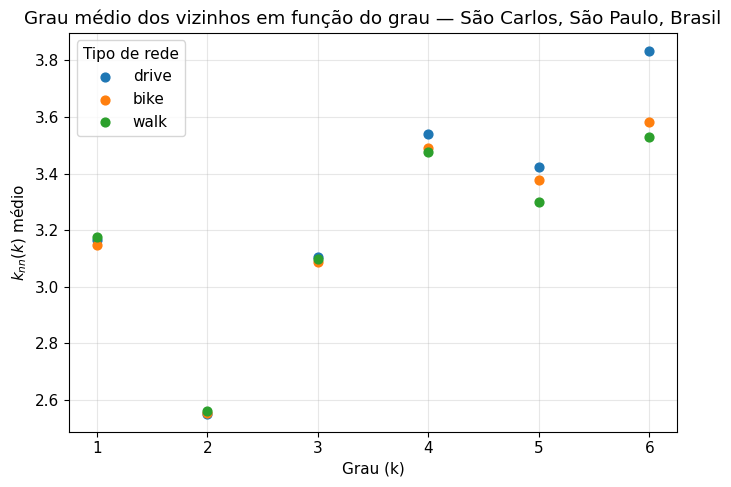

---------------------------- Rede tipo drive em Salvador, Bahia, Brasil ----------------------------
Grau médio dos vizinhos, em média sobre toda a rede (2.9464) VERSUS Grau médio da rede <k> (2.6000)
Coeficiente de assortatividade de grau (Newman): -0.0264
→ Correlação de grau próxima de neutra.

---------------------------- Rede tipo bike em Salvador, Bahia, Brasil -----------------------------
Grau médio dos vizinhos, em média sobre toda a rede (2.9303) VERSUS Grau médio da rede <k> (2.5461)
Coeficiente de assortatividade de grau (Newman): -0.0321
→ Correlação de grau próxima de neutra.

---------------------------- Rede tipo walk em Salvador, Bahia, Brasil -----------------------------
Grau médio dos vizinhos, em média sobre toda a rede (2.9637) VERSUS Grau médio da rede <k> (2.6104)
Coeficiente de assortatividade de grau (Newman): -0.0194
→ Correlação de grau próxima de neutra.



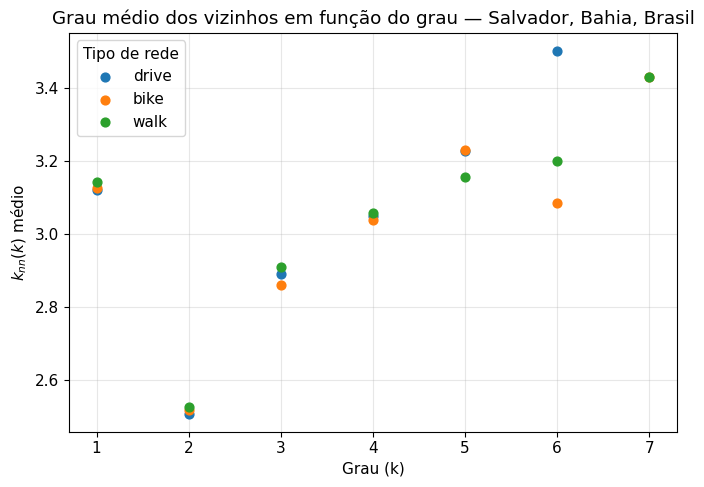

----------------------- Rede tipo drive em Vila Nery, São Carlos, SP, Brasil -----------------------
Grau médio dos vizinhos, em média sobre toda a rede (3.1188) VERSUS Grau médio da rede <k> (2.8618)
Coeficiente de assortatividade de grau (Newman): 0.1216
→ Rede levemente/fortemente assortativa: nós de grau parecido tendem a se conectar.

----------------------- Rede tipo bike em Vila Nery, São Carlos, SP, Brasil ------------------------
Grau médio dos vizinhos, em média sobre toda a rede (3.0728) VERSUS Grau médio da rede <k> (2.8048)
Coeficiente de assortatividade de grau (Newman): 0.1399
→ Rede levemente/fortemente assortativa: nós de grau parecido tendem a se conectar.

----------------------- Rede tipo walk em Vila Nery, São Carlos, SP, Brasil ------------------------
Grau médio dos vizinhos, em média sobre toda a rede (3.0749) VERSUS Grau médio da rede <k> (2.8081)
Coeficiente de assortatividade de grau (Newman): 0.1381
→ Rede levemente/fortemente assortativa: nós de grau pareci

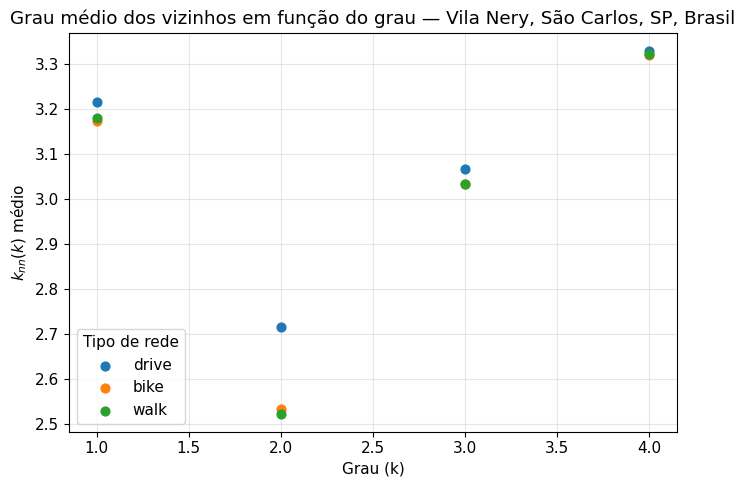

------------------------------------------- Erdos_Renyi --------------------------------------------
Knn médio geral (3.8206) VERSUS <k> (3.0119)
Assortatividade: -0.0012

----------------------------------------- Barabasi_Albert ------------------------------------------
Knn médio geral (16.0023) VERSUS <k> (3.9991)
Assortatividade: -0.0354



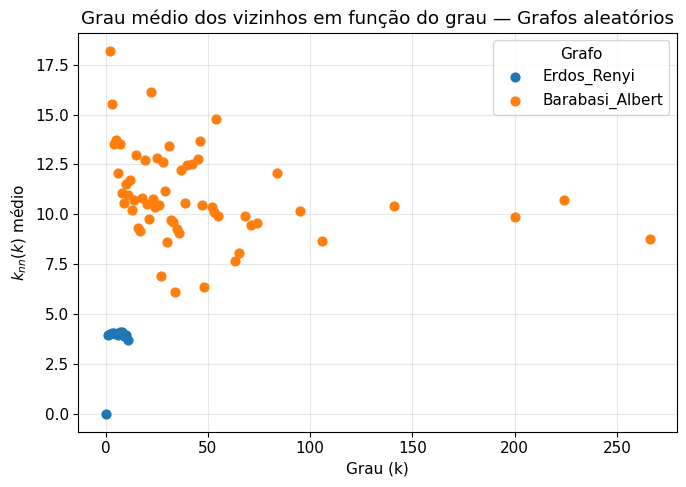

In [13]:
for lugar in lugares:
    fig, ax = plt.subplots(figsize=(7, 5))
    for tipo in tipos:
        G_osm = G_osm_place_and_type[lugar][tipo]
        G = preparar_grafo(G_osm)

        grau_medio = df_basico.loc[(df_basico["lugar"] == lugar) & (df_basico["tipo"] == tipo), "m1"].iloc[0]
        graus = np.array([grau for vertice, grau in G.degree()])

        knn_dict = nx.average_neighbor_degree(G)
        knn_vals = np.array(list(knn_dict.values()))
        knn_medio_geral = knn_vals.mean()

        print(f" Rede tipo {tipo} em {lugar} ".center(100, "-"))
        print(f"Grau médio dos vizinhos, em média sobre toda a rede ({knn_medio_geral:.4f}) VERSUS Grau médio da rede <k> ({grau_medio:.4f})")

        df_knn = pd.DataFrame({"grau": graus, "knn": knn_vals})
        knn_por_grau = df_knn.groupby("grau")["knn"].mean()

        ax.scatter(knn_por_grau.index, knn_por_grau.values, s=40, label=tipo, zorder=3)

        assortatividade = nx.degree_assortativity_coefficient(G)
        print(f"Coeficiente de assortatividade de grau (Newman): {assortatividade:.4f}")

        if assortatividade > 0.05:
            print("→ Rede levemente/fortemente assortativa: nós de grau parecido tendem a se conectar.")
        elif assortatividade < -0.05:
            print("→ Rede dissortativa: nós de grau alto tendem a se ligar a nós de grau baixo.")
        else:
            print("→ Correlação de grau próxima de neutra.")
        print()

    ax.set_xlabel("Grau (k)")
    ax.set_ylabel(r"$k_{nn}(k)$ médio")
    ax.set_title(f"Grau médio dos vizinhos em função do grau — {lugar}")
    ax.legend(title="Tipo de rede")
    plt.tight_layout()
    plt.show()

# --- Bloco separado: aleatórios ---
fig, ax = plt.subplots(figsize=(7, 5))
for nome in ["Erdos_Renyi", "Barabasi_Albert"]:
    G = preparar_grafo(G_osm_place_and_type[nome]["unique"])
    graus = np.array([grau for vertice, grau in G.degree()])
    grau_medio = graus.mean()

    knn_dict = nx.average_neighbor_degree(G)
    knn_vals = np.array(list(knn_dict.values()))
    knn_medio_geral = knn_vals.mean()

    print(f" {nome} ".center(100, "-"))
    print(f"Knn médio geral ({knn_medio_geral:.4f}) VERSUS <k> ({grau_medio:.4f})")

    df_knn = pd.DataFrame({"grau": graus, "knn": knn_vals})
    knn_por_grau = df_knn.groupby("grau")["knn"].mean()
    ax.scatter(knn_por_grau.index, knn_por_grau.values, s=40, label=nome, zorder=3)

    assortatividade = nx.degree_assortativity_coefficient(G)
    print(f"Assortatividade: {assortatividade:.4f}\n")

ax.set_xlabel("Grau (k)")
ax.set_ylabel(r"$k_{nn}(k)$ médio")
ax.set_title("Grau médio dos vizinhos em função do grau — Grafos aleatórios")
ax.legend(title="Grafo")
plt.tight_layout()
plt.show()

### 13. Índice h dos graus

O **índice h**, popularizado por Hirsch para medir produtividade científica, pode ser aplicado à sequência de graus de uma rede. Definição:

> O índice $h$ é o maior número tal que existam pelo menos $h$ nós com grau $\geq h$.

Formalmente, ordenando os graus em ordem decrescente $k_{(1)} \geq k_{(2)} \geq \dots \geq k_{(N)}$:

$$h = \max\{\, i : k_{(i)} \geq i \,\}$$

O índice h combina, em um único número, informação sobre **quantidade** de nós bem conectados e **magnitude** dos seus graus. É mais robusto a outliers extremos do que $k_{max}$ isoladamente.


Índice h da rede tipo drive em São Carlos, São Paulo, Brasil: h = 5
Interpretação: existem pelo menos 5 nós com grau maior ou igual a 5.

Índice h da rede tipo bike em São Carlos, São Paulo, Brasil: h = 5
Interpretação: existem pelo menos 5 nós com grau maior ou igual a 5.

Índice h da rede tipo walk em São Carlos, São Paulo, Brasil: h = 6
Interpretação: existem pelo menos 6 nós com grau maior ou igual a 6.



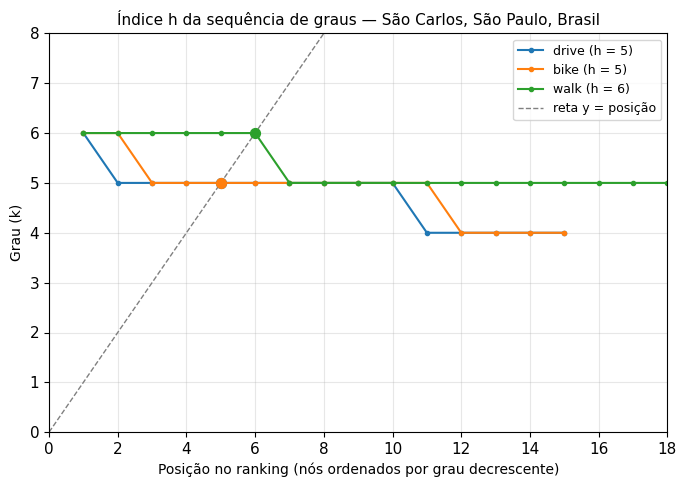

Índice h da rede tipo drive em Salvador, Bahia, Brasil: h = 5
Interpretação: existem pelo menos 5 nós com grau maior ou igual a 5.

Índice h da rede tipo bike em Salvador, Bahia, Brasil: h = 5
Interpretação: existem pelo menos 5 nós com grau maior ou igual a 5.

Índice h da rede tipo walk em Salvador, Bahia, Brasil: h = 6
Interpretação: existem pelo menos 6 nós com grau maior ou igual a 6.



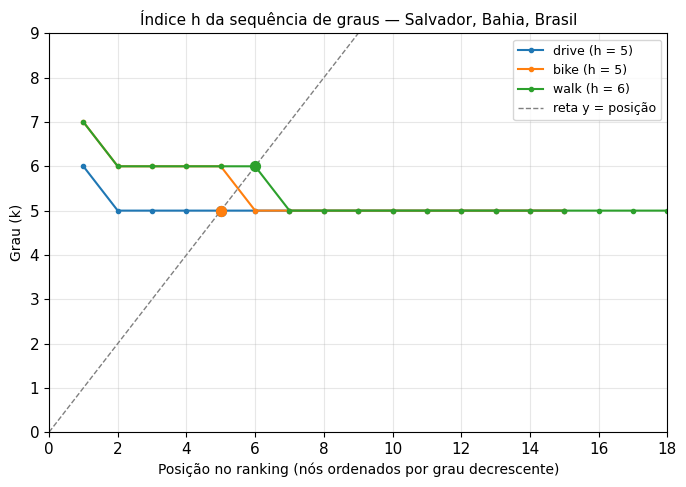

Índice h da rede tipo drive em Vila Nery, São Carlos, SP, Brasil: h = 4
Interpretação: existem pelo menos 4 nós com grau maior ou igual a 4.

Índice h da rede tipo bike em Vila Nery, São Carlos, SP, Brasil: h = 4
Interpretação: existem pelo menos 4 nós com grau maior ou igual a 4.

Índice h da rede tipo walk em Vila Nery, São Carlos, SP, Brasil: h = 4
Interpretação: existem pelo menos 4 nós com grau maior ou igual a 4.



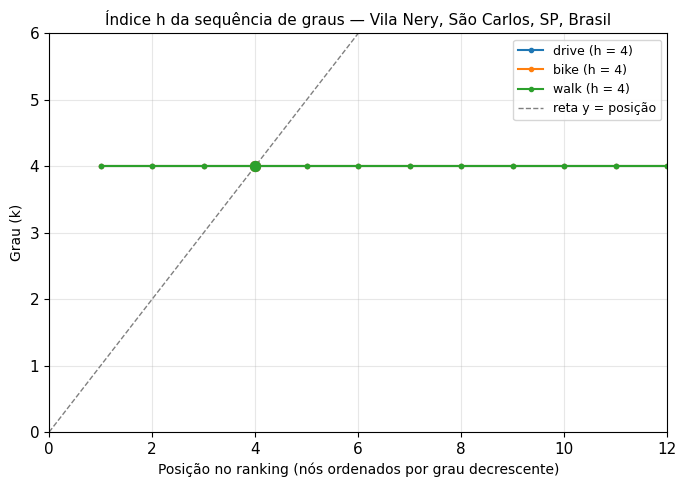

Índice h — Erdos_Renyi: h = 10
Índice h — Barabasi_Albert: h = 36


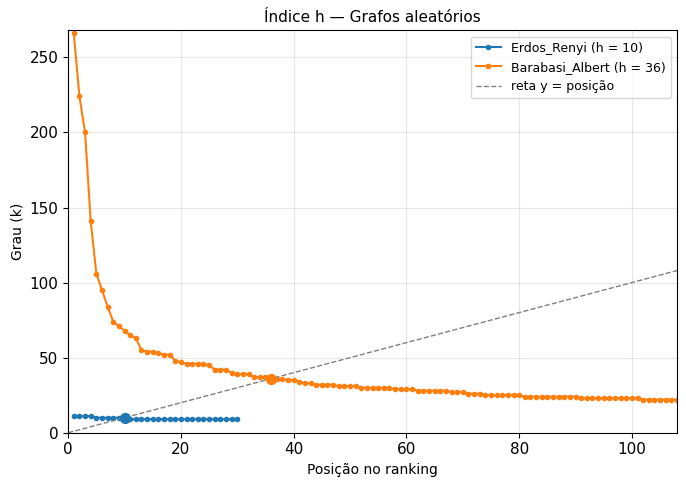

In [14]:
def indice_h(sequencia_graus):
    graus_ordenados = sorted(sequencia_graus, reverse=True)
    h = 0
    for posicao, k in enumerate(graus_ordenados, start=1):
        if k >= posicao:
            h = posicao
        else:
            break
    return h

df_basico["indice_h"] = np.nan

# --- Cidades: cálculo + plot comparativo por lugar (como antes) ---
for lugar in lugares:
    fig, ax = plt.subplots(figsize=(7, 5))
    limite_x_max = 0
    limite_y_max = 0
    for tipo in tipos:
        G_osm = G_osm_place_and_type[lugar][tipo]
        G = preparar_grafo(G_osm)

        graus = np.array([grau for vertice, grau in G.degree()])
        h = indice_h(graus)

        print(f"Índice h da rede tipo {tipo} em {lugar}: h = {h}")
        print(f"Interpretação: existem pelo menos {h} nós com grau maior ou igual a {h}.\n")

        df_basico.loc[(df_basico['lugar']==lugar)&(df_basico['tipo']==tipo), 'indice_h'] = h

        graus_ordenados = np.sort(graus)[::-1]
        posicoes = np.arange(1, len(graus_ordenados) + 1)

        limite_x = min(3 * h, len(graus_ordenados))
        limite_x_max = max(limite_x_max, limite_x)
        limite_y = (graus_ordenados[:limite_x].max() + 2)
        limite_y_max = max(limite_y_max, limite_y)

        ax.plot(posicoes[:limite_x], graus_ordenados[:limite_x], "-o",
                linewidth=1.5, markersize=3, label=f"{tipo} (h = {h})")
        ax.scatter(h, h, s=50, zorder=5)

    ax.plot([0, limite_x_max], [0, limite_x_max], color="gray", linestyle="--",
            linewidth=1, label="reta y = posição")
    ax.set_xlim(0, limite_x_max)
    ax.set_ylim(0, limite_y_max)
    ax.set_xlabel("Posição no ranking (nós ordenados por grau decrescente)", fontsize=10)
    ax.set_ylabel("Grau (k)", fontsize=10)
    ax.set_title(f"Índice h da sequência de graus — {lugar}", fontsize=11)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

# --- Aleatórios: cálculo (preenche df_basico) + plot comparativo entre os dois ---
fig, ax = plt.subplots(figsize=(7, 5))
limite_x_max = 0
limite_y_max = 0
for nome in ["Erdos_Renyi", "Barabasi_Albert"]:
    G = preparar_grafo(G_osm_place_and_type[nome]["unique"])
    graus = np.array([grau for vertice, grau in G.degree()])
    h = indice_h(graus)

    print(f"Índice h — {nome}: h = {h}")
    df_basico.loc[(df_basico['lugar']==nome)&(df_basico['tipo']=='unique'), 'indice_h'] = h

    graus_ordenados = np.sort(graus)[::-1]
    posicoes = np.arange(1, len(graus_ordenados) + 1)
    limite_x = min(3 * h, len(graus_ordenados))
    limite_x_max = max(limite_x_max, limite_x)
    limite_y_max = max(limite_y_max, graus_ordenados[:limite_x].max() + 2)

    ax.plot(posicoes[:limite_x], graus_ordenados[:limite_x], "-o",
            linewidth=1.5, markersize=3, label=f"{nome} (h = {h})")
    ax.scatter(h, h, s=50, zorder=5)

ax.plot([0, limite_x_max], [0, limite_x_max], color="gray", linestyle="--",
        linewidth=1, label="reta y = posição")
ax.set_xlim(0, limite_x_max)
ax.set_ylim(0, limite_y_max)
ax.set_xlabel("Posição no ranking", fontsize=10)
ax.set_ylabel("Grau (k)", fontsize=10)
ax.set_title("Índice h — Grafos aleatórios", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 14. Coeficiente de Gini dos graus

Emprestado da economia (onde mede desigualdade de renda), o **coeficiente de Gini** aplicado aos graus quantifica o quão desigualmente a conectividade está distribuída entre os nós:

$$G = \frac{\sum_{i=1}^N \sum_{j=1}^N |k_i - k_j|}{2N^2 \langle k \rangle}$$

- $G = 0$: todos os nós têm exatamente o mesmo grau (igualdade perfeita).
- $G \to 1$: a conectividade está extremamente concentrada em poucos nós (forte desigualdade).

Uma forma equivalente e mais eficiente de calcular usa a **curva de Lorenz** dos graus ordenados.


Coeficiente de Gini dos graus — São Carlos, São Paulo, Brasil / drive: 0.1280
Coeficiente de Gini dos graus — São Carlos, São Paulo, Brasil / bike: 0.1339
Coeficiente de Gini dos graus — São Carlos, São Paulo, Brasil / walk: 0.1337


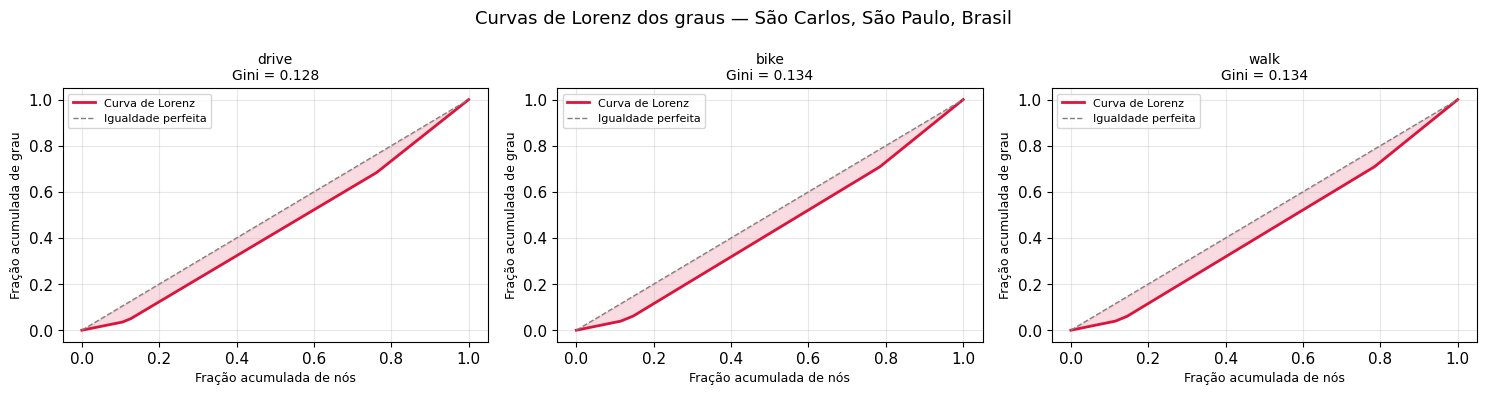

Coeficiente de Gini dos graus — Salvador, Bahia, Brasil / drive: 0.1649
Coeficiente de Gini dos graus — Salvador, Bahia, Brasil / bike: 0.1806
Coeficiente de Gini dos graus — Salvador, Bahia, Brasil / walk: 0.1690


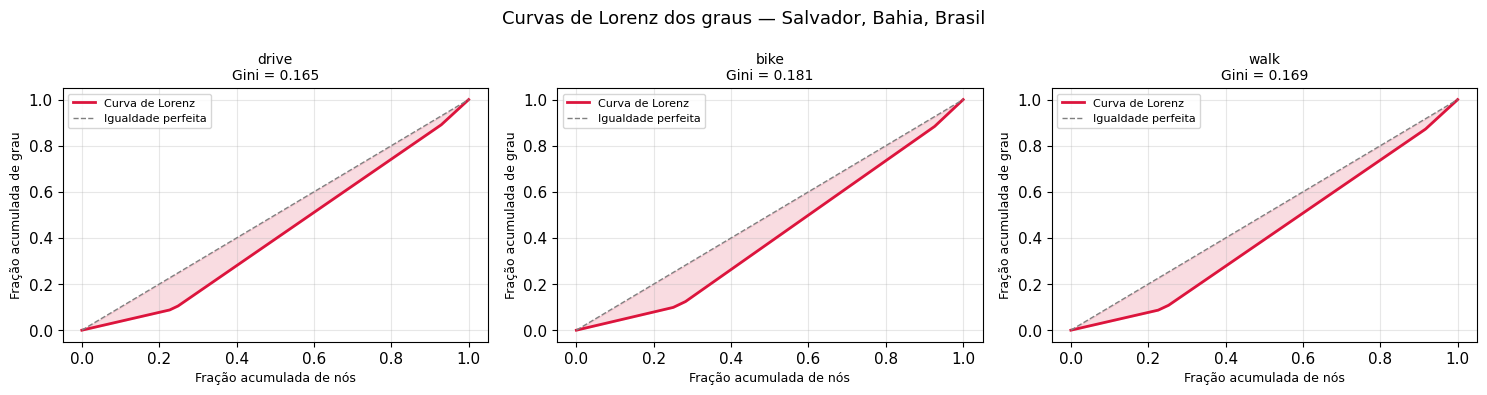

Coeficiente de Gini dos graus — Vila Nery, São Carlos, SP, Brasil / drive: 0.1473
Coeficiente de Gini dos graus — Vila Nery, São Carlos, SP, Brasil / bike: 0.1541
Coeficiente de Gini dos graus — Vila Nery, São Carlos, SP, Brasil / walk: 0.1528


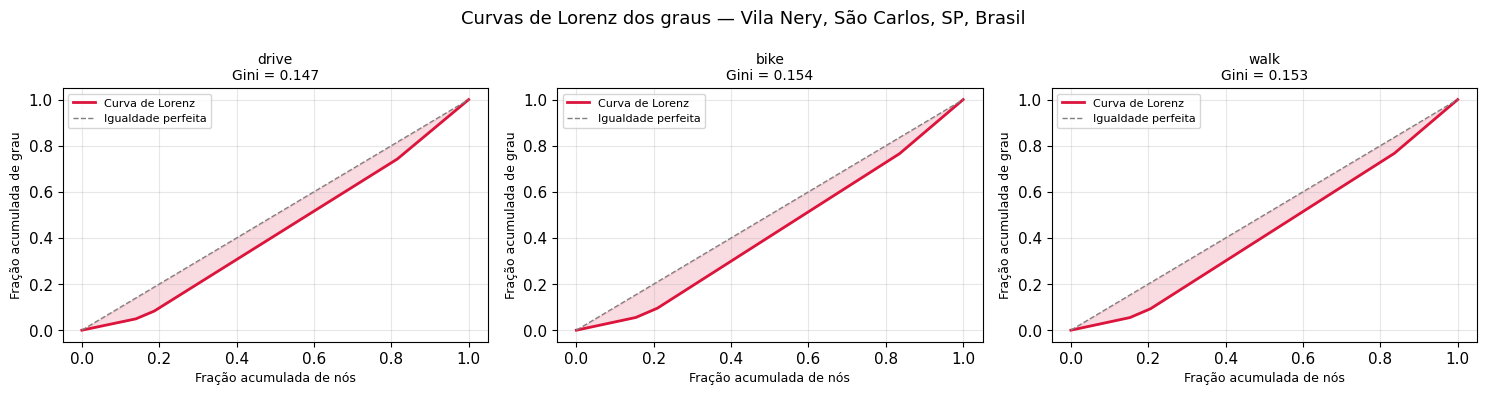

Coeficiente de Gini dos graus — Erdos_Renyi: 0.3199
Coeficiente de Gini dos graus — Barabasi_Albert: 0.3889


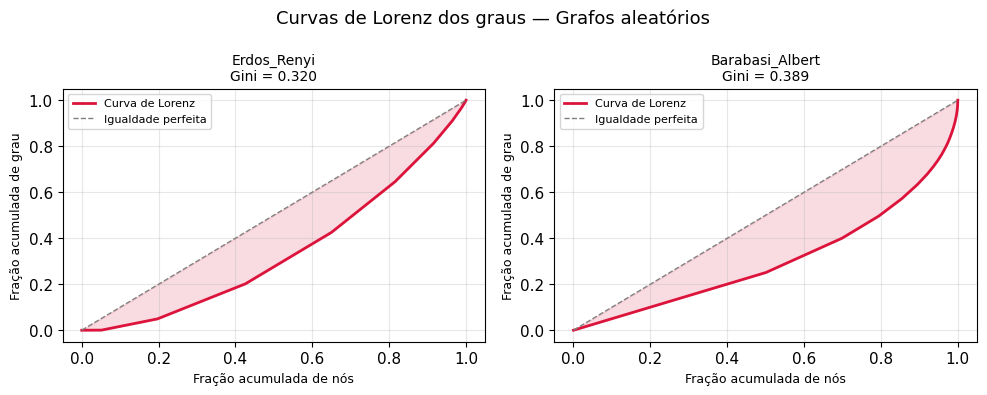

In [15]:
def coeficiente_gini(sequencia):
    x = np.sort(np.array(sequencia, dtype=float))
    n = len(x)
    soma_cumulativa = np.cumsum(x)
    return (n + 1 - 2 * np.sum(soma_cumulativa) / soma_cumulativa[-1]) / n

df_basico["coeficiente_gini"] = np.nan

def plot_lorenz(ax, graus, titulo):
    gini_k = coeficiente_gini(graus)
    graus_ordenados_asc = np.sort(graus)
    soma_cum = np.cumsum(graus_ordenados_asc)
    lorenz = np.insert(soma_cum / soma_cum[-1], 0, 0)
    eixo_populacao = np.linspace(0, 1, len(lorenz))

    ax.plot(eixo_populacao, lorenz, color="crimson", linewidth=2, label="Curva de Lorenz")
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Igualdade perfeita")
    ax.fill_between(eixo_populacao, lorenz, eixo_populacao, color="crimson", alpha=0.15)
    ax.set_xlabel("Fração acumulada de nós", fontsize=9)
    ax.set_ylabel("Fração acumulada de grau", fontsize=9)
    ax.set_title(f"{titulo}\nGini = {gini_k:.3f}", fontsize=10)
    ax.legend(fontsize=8)
    return gini_k

# --- Cidades: cálculo + plot comparativo por lugar (como antes) ---
for lugar in lugares:
    fig, axes = plt.subplots(1, len(tipos), figsize=(15, 4))
    for i, tipo in enumerate(tipos):
        G_osm = G_osm_place_and_type[lugar][tipo]
        G = preparar_grafo(G_osm)
        graus = np.array([grau for vertice, grau in G.degree()])

        gini_k = plot_lorenz(axes[i], graus, tipo)
        print(f"Coeficiente de Gini dos graus — {lugar} / {tipo}: {gini_k:.4f}")

        df_basico.loc[(df_basico['lugar']==lugar)&(df_basico['tipo']==tipo), "coeficiente_gini"] = gini_k

    fig.suptitle(f"Curvas de Lorenz dos graus — {lugar}", fontsize=13)
    plt.tight_layout()
    plt.show()

# --- Aleatórios: cálculo + plot lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, nome in enumerate(["Erdos_Renyi", "Barabasi_Albert"]):
    G = preparar_grafo(G_osm_place_and_type[nome]["unique"])
    graus = np.array([grau for vertice, grau in G.degree()])

    gini_k = plot_lorenz(axes[i], graus, nome)
    print(f"Coeficiente de Gini dos graus — {nome}: {gini_k:.4f}")

    df_basico.loc[(df_basico['lugar']==nome)&(df_basico['tipo']=='unique'), "coeficiente_gini"] = gini_k

fig.suptitle("Curvas de Lorenz dos graus — Grafos aleatórios", fontsize=13)
plt.tight_layout()
plt.show()

### 15. Tabela-resumo

Consolidamos abaixo todas as medidas calculadas ao longo do notebook em uma única tabela, útil para relatórios ou para comparar diferentes redes/cidades.

In [26]:
display(
        df_basico.style.format({
            "nos_bruto": "{:.0f}",
            "arestas_bruto": "{:.0f}",
            "nos": "{:.0f}",
            "arestas": "{:.0f}",
            "grau_medio_2E": "{:.3f}",
            "m1": "{:.3f}",
            "m2": "{:.3f}",
            "m3": "{:.3f}",
            "var_k": "{:.3f}",
            "std_k": "{:.3f}",
            "cv_k": "{:.4f}",
            "Entropia_H(K)": "{:.4f}",
            "H_max_possivel": "{:.4f}",
            "H_norm": "{:.4f}",
            "indice_h": "{:.0f}",
            "coeficiente_gini": "{:.4f}"
        }) 
    )

df_basico.to_csv("df_basico.csv", index=False, encoding="utf-8-sig")
print("Arquivo salvo: df_basico.csv")

,lugar,tipo,nos_bruto,arestas_bruto,nos,arestas,grau_medio_2E,m1,m2,m3,var_k,std_k,cv_k,Entropia_H(K),H_max_possivel,H_norm,indice_h,coeficiente_gini
0,"São Carlos, São Paulo, Brasil",drive,9218,22638,9218,13882,3.012,3.012,9.751,32.834,0.679,0.824,0.2736,1.3770,8.0498,0.1711,5,0.1280
1,"São Carlos, São Paulo, Brasil",bike,11836,29964,11836,17509,2.959,2.959,9.459,31.532,0.705,0.840,0.2839,1.4175,8.0498,0.1761,5,0.1339
2,"São Carlos, São Paulo, Brasil",walk,12644,37926,12644,18719,2.961,2.961,9.475,31.622,0.707,0.841,0.2841,1.4140,8.0498,0.1757,6,0.1337
3,"Salvador, Bahia, Brasil",drive,28215,64717,28215,36680,2.600,2.600,7.600,23.447,0.839,0.916,0.3524,1.2617,8.0498,0.1567,5,0.1649
4,"Salvador, Bahia, Brasil",bike,43752,99319,43752,55699,2.546,2.546,7.385,22.780,0.902,0.950,0.3731,1.3554,8.0498,0.1684,5,0.1806
5,"Salvador, Bahia, Brasil",walk,50231,133176,50231,65561,2.610,2.610,7.677,23.886,0.863,0.929,0.3558,1.3287,8.0498,0.1651,6,0.1690
6,"Vila Nery, São Carlos, SP, Brasil",drive,738,1835,738,1056,2.862,2.862,8.957,29.374,0.767,0.876,0.3060,1.4751,8.0498,0.1832,4,0.1473
7,"Vila Nery, São Carlos, SP, Brasil",bike,840,2107,840,1178,2.805,2.805,8.660,28.098,0.793,0.890,0.3175,1.4987,8.0498,0.1862,4,0.1541
8,"Vila Nery, São Carlos, SP, Brasil",walk,844,2394,844,1185,2.808,2.808,8.673,28.137,0.788,0.888,0.3161,1.4864,8.0498,0.1847,4,0.1528
9,Erdos_Renyi,unique,9218,13882,9218,13882,3.012,3.012,12.131,58.238,3.060,1.749,0.5807,2.7958,8.0498,0.3473,10,0.3199


Arquivo salvo: df_basico.csv


### 16. Correlação entre `knn` e o grau de cada nó

------------------------------ São Carlos, São Paulo, Brasil / drive -------------------------------
Correlação de Pearson (knn vs grau, por nó): 0.2801  (p-valor: 9.64e-166)
Correlação de Spearman (knn vs grau, por nó): 0.4214  (p-valor: 0.00e+00)

------------------------------- São Carlos, São Paulo, Brasil / bike -------------------------------
Correlação de Pearson (knn vs grau, por nó): 0.2503  (p-valor: 1.41e-168)
Correlação de Spearman (knn vs grau, por nó): 0.3861  (p-valor: 0.00e+00)

------------------------------- São Carlos, São Paulo, Brasil / walk -------------------------------
Correlação de Pearson (knn vs grau, por nó): 0.2237  (p-valor: 4.11e-143)
Correlação de Spearman (knn vs grau, por nó): 0.3594  (p-valor: 0.00e+00)



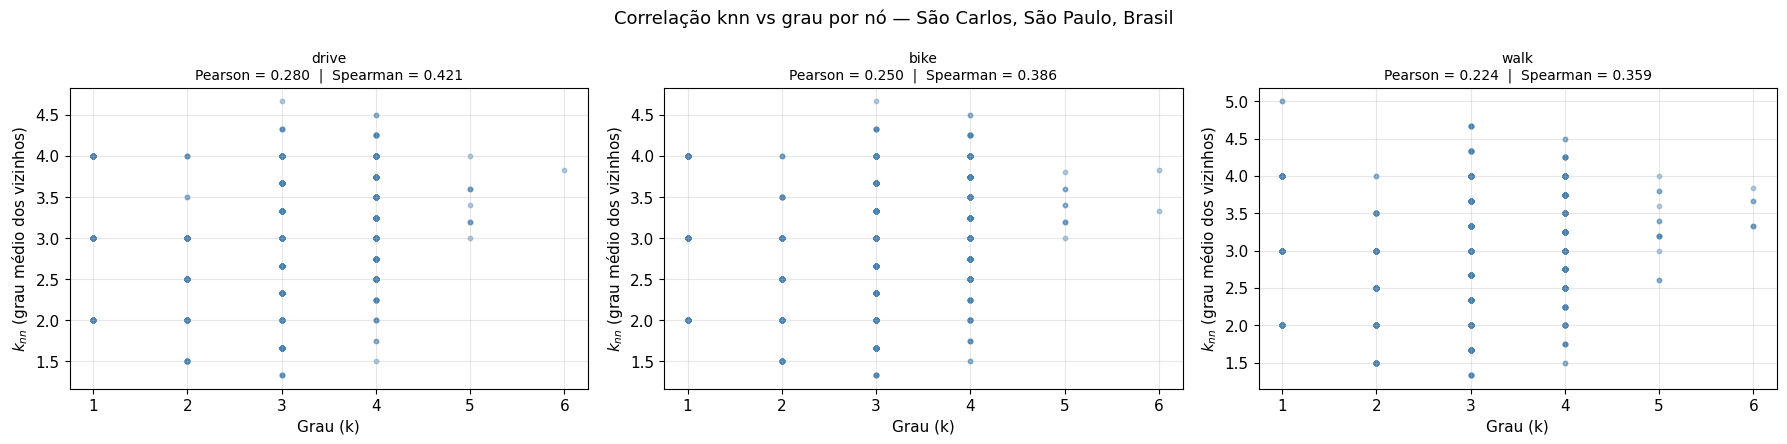

--------------------------------- Salvador, Bahia, Brasil / drive ----------------------------------
Correlação de Pearson (knn vs grau, por nó): -0.1582  (p-valor: 1.56e-157)
Correlação de Spearman (knn vs grau, por nó): -0.0471  (p-valor: 2.31e-15)

---------------------------------- Salvador, Bahia, Brasil / bike ----------------------------------
Correlação de Pearson (knn vs grau, por nó): -0.1793  (p-valor: 6.76e-313)
Correlação de Spearman (knn vs grau, por nó): -0.0780  (p-valor: 4.81e-60)

---------------------------------- Salvador, Bahia, Brasil / walk ----------------------------------
Correlação de Pearson (knn vs grau, por nó): -0.1477  (p-valor: 6.14e-243)
Correlação de Spearman (knn vs grau, por nó): -0.0338  (p-valor: 3.71e-14)



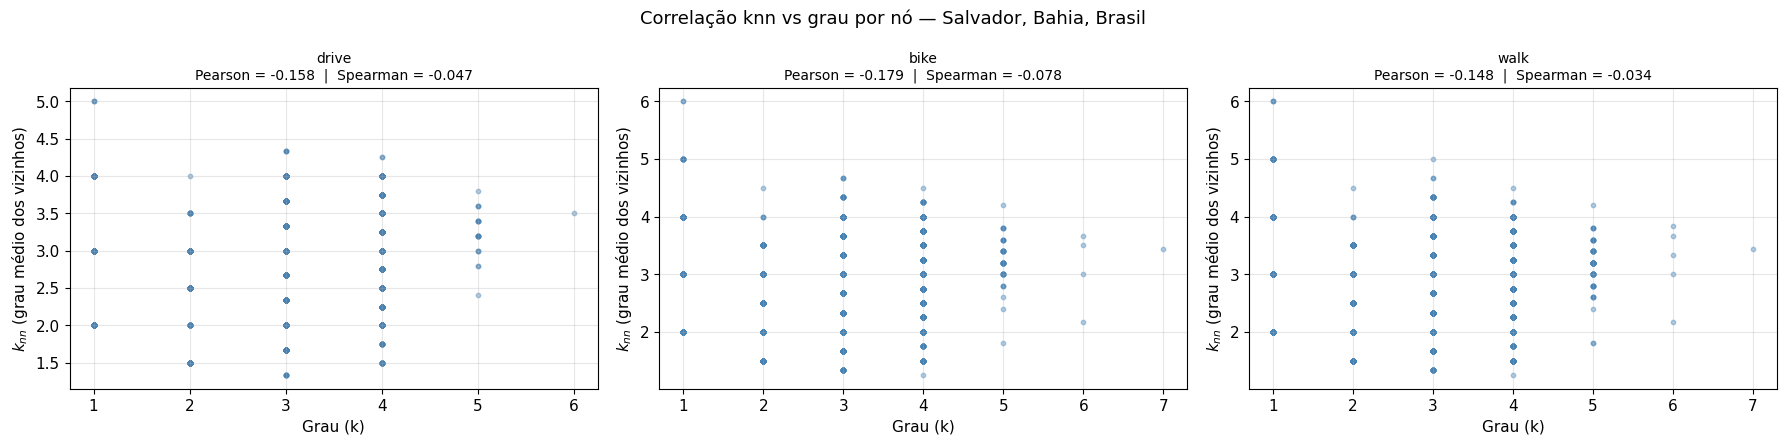

---------------------------- Vila Nery, São Carlos, SP, Brasil / drive -----------------------------
Correlação de Pearson (knn vs grau, por nó): 0.0783  (p-valor: 3.34e-02)
Correlação de Spearman (knn vs grau, por nó): 0.1864  (p-valor: 3.38e-07)

----------------------------- Vila Nery, São Carlos, SP, Brasil / bike -----------------------------
Correlação de Pearson (knn vs grau, por nó): 0.0976  (p-valor: 4.62e-03)
Correlação de Spearman (knn vs grau, por nó): 0.2130  (p-valor: 4.51e-10)

----------------------------- Vila Nery, São Carlos, SP, Brasil / walk -----------------------------
Correlação de Pearson (knn vs grau, por nó): 0.0922  (p-valor: 7.35e-03)
Correlação de Spearman (knn vs grau, por nó): 0.2112  (p-valor: 5.72e-10)



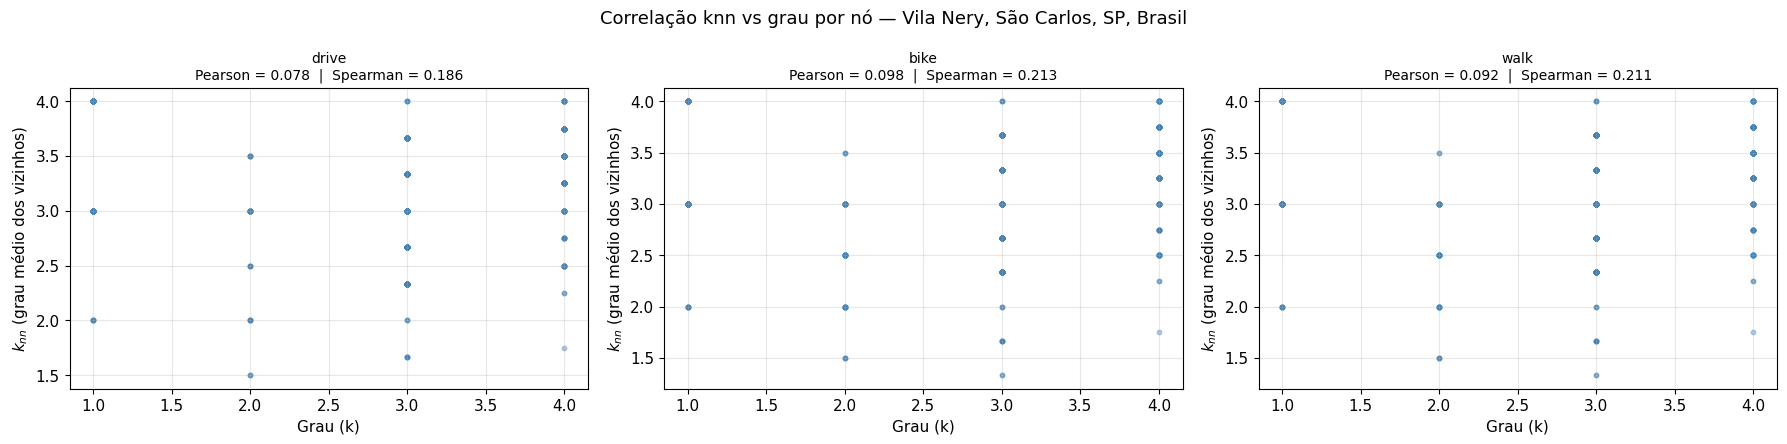

------------------------------------------- Erdos_Renyi --------------------------------------------
Correlação de Pearson (knn vs grau, por nó): 0.2511  (p-valor: 1.65e-132)
Correlação de Spearman (knn vs grau, por nó): 0.1800  (p-valor: 5.95e-68)

----------------------------------------- Barabasi_Albert ------------------------------------------
Correlação de Pearson (knn vs grau, por nó): -0.0543  (p-valor: 1.87e-07)
Correlação de Spearman (knn vs grau, por nó): -0.0712  (p-valor: 7.96e-12)



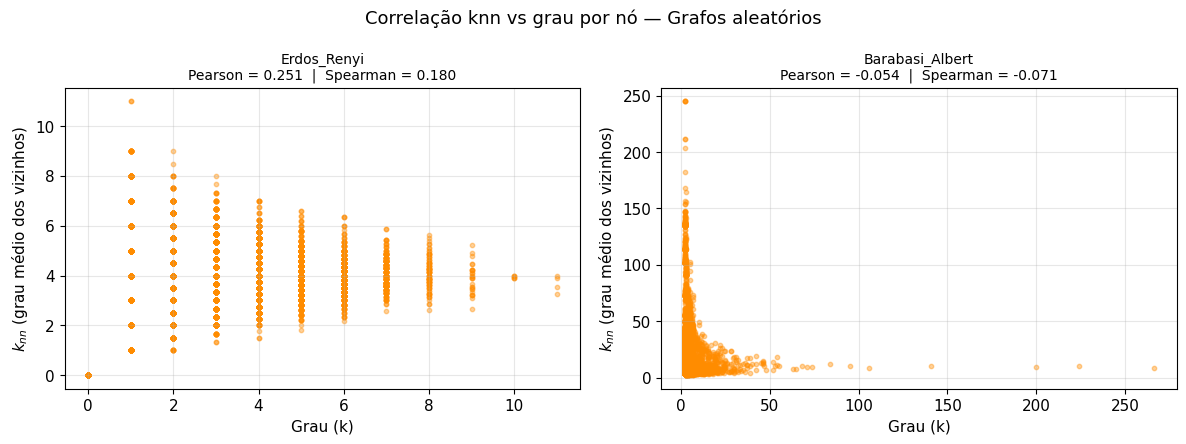

,lugar,tipo,correlacao_pearson,correlacao_spearman
0,"São Carlos, São Paulo, Brasil",drive,0.2801,0.4214
1,"São Carlos, São Paulo, Brasil",bike,0.2503,0.3861
2,"São Carlos, São Paulo, Brasil",walk,0.2237,0.3594
3,"Salvador, Bahia, Brasil",drive,-0.1582,-0.0471
4,"Salvador, Bahia, Brasil",bike,-0.1793,-0.0780
5,"Salvador, Bahia, Brasil",walk,-0.1477,-0.0338
6,"Vila Nery, São Carlos, SP, Brasil",drive,0.0783,0.1864
7,"Vila Nery, São Carlos, SP, Brasil",bike,0.0976,0.2130
8,"Vila Nery, São Carlos, SP, Brasil",walk,0.0922,0.2112
9,Erdos_Renyi,unique,0.2511,0.1800


In [19]:
df_corr_knn = pd.DataFrame(columns=["lugar", "tipo", "correlacao_pearson", "correlacao_spearman"])

# --- Cidades/bairro: subplots lado a lado por tipo, dentro de um mesmo lugar ---
for lugar in lugares:
    fig, axes = plt.subplots(1, len(tipos), figsize=(6 * len(tipos), 4.5))
    if len(tipos) == 1:
        axes = [axes]

    for ax, tipo in zip(axes, tipos):
        G_osm = G_osm_place_and_type[lugar][tipo]
        G = preparar_grafo(G_osm)

        graus_dict = dict(G.degree())
        knn_dict = nx.average_neighbor_degree(G)

        nos = list(G.nodes())
        graus = np.array([graus_dict[n] for n in nos])
        knn_vals = np.array([knn_dict[n] for n in nos])

        corr_pearson, p_pearson = stats.pearsonr(graus, knn_vals)
        corr_spearman, p_spearman = stats.spearmanr(graus, knn_vals)

        df_corr_knn.loc[len(df_corr_knn)] = [lugar, tipo, corr_pearson, corr_spearman]

        print(f" {lugar} / {tipo} ".center(100, "-"))
        print(f"Correlação de Pearson (knn vs grau, por nó): {corr_pearson:.4f}  (p-valor: {p_pearson:.2e})")
        print(f"Correlação de Spearman (knn vs grau, por nó): {corr_spearman:.4f}  (p-valor: {p_spearman:.2e})\n")

        ax.scatter(graus, knn_vals, s=10, alpha=0.4, color="steelblue")
        ax.set_xlabel("Grau (k)")
        ax.set_ylabel(r"$k_{nn}$ (grau médio dos vizinhos)")
        ax.set_title(f"{tipo}\nPearson = {corr_pearson:.3f}  |  Spearman = {corr_spearman:.3f}", fontsize=10)

    fig.suptitle(f"Correlação knn vs grau por nó — {lugar}", fontsize=13)
    plt.tight_layout()
    plt.show()

# --- Aleatórios: subplots lado a lado, cada um com seu único grafo ---
nomes_aleatorios = ["Erdos_Renyi", "Barabasi_Albert"]
fig, axes = plt.subplots(1, len(nomes_aleatorios), figsize=(6 * len(nomes_aleatorios), 4.5))

for ax, nome in zip(axes, nomes_aleatorios):
    G = preparar_grafo(G_osm_place_and_type[nome]["unique"])

    graus_dict = dict(G.degree())
    knn_dict = nx.average_neighbor_degree(G)

    nos = list(G.nodes())
    graus = np.array([graus_dict[n] for n in nos])
    knn_vals = np.array([knn_dict[n] for n in nos])

    corr_pearson, p_pearson = stats.pearsonr(graus, knn_vals)
    corr_spearman, p_spearman = stats.spearmanr(graus, knn_vals)

    df_corr_knn.loc[len(df_corr_knn)] = [nome, "unique", corr_pearson, corr_spearman]

    print(f" {nome} ".center(100, "-"))
    print(f"Correlação de Pearson (knn vs grau, por nó): {corr_pearson:.4f}  (p-valor: {p_pearson:.2e})")
    print(f"Correlação de Spearman (knn vs grau, por nó): {corr_spearman:.4f}  (p-valor: {p_spearman:.2e})\n")

    ax.scatter(graus, knn_vals, s=10, alpha=0.4, color="darkorange")
    ax.set_xlabel("Grau (k)")
    ax.set_ylabel(r"$k_{nn}$ (grau médio dos vizinhos)")
    ax.set_title(f"{nome}\nPearson = {corr_pearson:.3f}  |  Spearman = {corr_spearman:.3f}", fontsize=10)

fig.suptitle("Correlação knn vs grau por nó — Grafos aleatórios", fontsize=13)
plt.tight_layout()
plt.show()

display(df_corr_knn.style.format({"correlacao_pearson": "{:.4f}", "correlacao_spearman": "{:.4f}"}))

In [25]:
def simulacao_robustez(G, frac_remocao=0.10, n_simulacoes=25, seed=42):
    rng = np.random.default_rng(seed)

    valores_h = []
    valores_k_max = []
    nos_restantes_por_simulacao = []

    G_atual = G.copy()  # grafo que vai encolhendo a cada iteração

    for i in range(n_simulacoes):
        n_nos_atual = G_atual.number_of_nodes()
        n_remover = int(round(frac_remocao * n_nos_atual))

        nos_atuais = list(G_atual.nodes())
        nos_remover = rng.choice(nos_atuais, size=n_remover, replace=False)

        G_atual = G_atual.copy()
        G_atual.remove_nodes_from(nos_remover)

        graus_sub = np.array([grau for _, grau in G_atual.degree()])

        h_sub = indice_h(graus_sub)
        k_max_sub = graus_sub.max()

        valores_h.append(h_sub)
        valores_k_max.append(k_max_sub)
        nos_restantes_por_simulacao.append(G_atual.number_of_nodes())

        print(f"  Simulação {i+1}/{n_simulacoes}: grafo tinha {n_nos_atual} nós → "
              f"removidos {n_remover} ({frac_remocao*100:.0f}% do que restava) → "
              f"restaram {G_atual.number_of_nodes()} nós | "
              f"índice h = {h_sub} | grau máximo = {k_max_sub}")

    return np.array(valores_h), np.array(valores_k_max)


df_robustez = pd.DataFrame(
    columns=["lugar", "tipo", "h_original", "h_medio", "h_std", "h_cv",
             "k_max_original", "k_max_medio", "k_max_std", "k_max_cv"]
)

resultados_simulacao = {}  # guarda os arrays brutos para plot depois

# Considera apenas o tipo 'drive' entre as redes viárias, mantendo os grafos aleatórios (tipo 'unique')
combinacoes_filtradas = [(lugar, tipo) for lugar, tipo in combinacoes if tipo in ("drive", "unique")]

for lugar, tipo in combinacoes_filtradas:
    G_osm = G_osm_place_and_type[lugar][tipo]
    G = preparar_grafo(G_osm)

    graus_original = np.array([grau for _, grau in G.degree()])
    h_original = indice_h(graus_original)
    k_max_original = graus_original.max()

    print(f" {lugar} / {tipo} ".center(100, "="))
    print(f"Rede original: {G.number_of_nodes()} nós | índice h = {h_original} | grau máximo = {k_max_original}")
    print(f"Iniciando simulação de Monte Carlo CUMULATIVA: cada rodada remove 10% dos nós que restaram na rodada anterior (3 rodadas)...\n")

    valores_h, valores_k_max = simulacao_robustez(G, frac_remocao=0.10, n_simulacoes=25, seed=42)
    resultados_simulacao[(lugar, tipo)] = (valores_h, valores_k_max)

    h_medio, h_std = valores_h.mean(), valores_h.std()
    k_max_medio, k_max_std = valores_k_max.mean(), valores_k_max.std()

    h_cv = h_std / h_medio if h_medio > 0 else np.nan
    k_max_cv = k_max_std / k_max_medio if k_max_medio > 0 else np.nan

    df_robustez.loc[len(df_robustez)] = [
        lugar, tipo, h_original, h_medio, h_std, h_cv,
        k_max_original, k_max_medio, k_max_std, k_max_cv
    ]

    print(f"\nResumo após as 3 remoções cumulativas:")
    print(f"  Índice h        → original: {h_original:>6}  |  média: {h_medio:6.2f}  |  desvio padrão: {h_std:6.3f}  |  CV: {h_cv:.4f}")
    print(f"  Grau máximo     → original: {k_max_original:>6}  |  média: {k_max_medio:6.2f}  |  desvio padrão: {k_max_std:6.3f}  |  CV: {k_max_cv:.4f}")

    medida_mais_estavel = "índice h" if h_cv < k_max_cv else "grau máximo"
    print(f"  → Medida mais estável (menor coeficiente de variação): {medida_mais_estavel}\n")

display(
    df_robustez.style.format({
        "h_original": "{:.0f}", "h_medio": "{:.2f}", "h_std": "{:.3f}", "h_cv": "{:.4f}",
        "k_max_original": "{:.0f}", "k_max_medio": "{:.2f}", "k_max_std": "{:.3f}", "k_max_cv": "{:.4f}"
    })
)

============================== São Carlos, São Paulo, Brasil / drive ===============================
Rede original: 9218 nós | índice h = 5 | grau máximo = 6
Iniciando simulação de Monte Carlo CUMULATIVA: cada rodada remove 10% dos nós que restaram na rodada anterior (3 rodadas)...

  Simulação 1/25: grafo tinha 9218 nós → removidos 922 (10% do que restava) → restaram 8296 nós | índice h = 5 | grau máximo = 5
  Simulação 2/25: grafo tinha 8296 nós → removidos 830 (10% do que restava) → restaram 7466 nós | índice h = 4 | grau máximo = 5
  Simulação 3/25: grafo tinha 7466 nós → removidos 747 (10% do que restava) → restaram 6719 nós | índice h = 4 | grau máximo = 4
  Simulação 4/25: grafo tinha 6719 nós → removidos 672 (10% do que restava) → restaram 6047 nós | índice h = 4 | grau máximo = 4
  Simulação 5/25: grafo tinha 6047 nós → removidos 605 (10% do que restava) → restaram 5442 nós | índice h = 4 | grau máximo = 4
  Simulação 6/25: grafo tinha 5442 nós → removidos 544 (10% do que rest

,lugar,tipo,h_original,h_medio,h_std,h_cv,k_max_original,k_max_medio,k_max_std,k_max_cv
0,"São Carlos, São Paulo, Brasil",drive,5,3.28,0.873,0.2661,6,3.52,0.854,0.2427
1,"Salvador, Bahia, Brasil",drive,5,3.40,0.800,0.2353,6,3.96,0.958,0.2420
2,"Vila Nery, São Carlos, SP, Brasil",drive,4,2.56,1.098,0.4290,4,3.08,1.163,0.3777
3,Erdos_Renyi,unique,10,4.48,2.119,0.4730,11,5.56,2.743,0.4934
4,Barabasi_Albert,unique,36,13.56,8.035,0.5926,266,78.12,61.997,0.7936


## Exercícios

1. **Outra cidade**: repita toda a análise para uma cidade diferente (por exemplo, sua cidade natal) e compare a tabela-resumo com a obtida aqui para São Carlos. O que muda? O que permanece parecido?

    - Analisei as cidades: São Carlos e São Paulo

2. **Tipo de rede**: refaça o download usando `network_type="walk"` (rede para pedestres) ou `network_type="bike"` em vez de `"drive"`. As medidas de grau mudam significativamente? Por quê?

    - Para cada local analisei 'drive', 'walk' e 'bike'
    - As medidas de grau mudaram pouco, os grafos são muito parecidos e suas medidas também.

3. **Bairro vs. cidade**: use `ox.graph_from_address()` ou `ox.graph_from_point()` com um raio pequeno (ex: 1 km) para extrair a rede de um bairro específico e compare suas medidas de grau com as da cidade inteira.

    - Analisei o bairro Vila Nery de São Carlos.
    - Notou-se que o grau médio deste bairro foi menor que ao da cidade, os maiores graus do bairro são menores que os da cidade, o que indica que o bairro não têm cruzamentos com tantas vias interligadas. Além disso, o CV mostrou-se maior no bairro do que na cidade (Lei dos grandes números?), assim como a entropia e coeficiente de gini.

4. **Redes aleatórias de comparação**: gere um grafo aleatório de Erdős–Rényi (`nx.gnm_random_graph`) e um grafo livre de escala (`nx.barabasi_albert_graph`) com o mesmo número de nós e arestas (aproximadamente) da rede viária. Compare a entropia, o coeficiente de variação e o coeficiente de Gini dos três grafos. Qual medida mais evidencia a diferença entre eles?

    - Como os grafos são aleatórios, as medidas de dispersão de grau mostraram-se bem maiores (variância, desvio padrão, coeficiente de variação, entropia, indice h e coeficiente de gini)

5. **Correlação entre medidas**: calcule a correlação entre `knn` e grau para cada nó individualmente (não agregado por classe de grau) e visualize um scatter plot. Isso reforça ou contradiz o coeficiente de assortatividade calculado na Seção 12?

6. **Robustez do índice h**: remova aleatoriamente 10% dos nós da rede e recalcule o índice h e o grau máximo. Repita esse processo várias vezes (simulação de Monte Carlo) e compare a variabilidade das duas medidas. Qual delas é mais estável?

    - Reforçou

não há um vencedor absoluto e consistente nas redes viárias reais — os CVs de índice h e grau máximo ficam muito próximos entre si nesses casos (diferenças de poucos pontos percentuais, ora um vence ora outro), porque a distribuição de grau nessas redes é naturalmente estreita e ambas as medidas colapsam de forma parecida sob remoção progressiva de nós.

A diferença fica clara nos grafos com distribuição de grau mais heterogênea, especialmente o Barabási-Albert: ali o grau máximo tem CV = 0.7936, bem mais alto que o índice h (CV = 0.4930), e a queda absoluta também é reveladora — o grau máximo caiu de 266 para uma média de ~78 (queda de ~71%), enquanto o índice h caiu de 36 para ~13.6 (queda de ~62%). Isso acontece porque o grau máximo depende de um único nó extremo (o maior hub) — remover justamente esse nó ou seus vizinhos de alto grau derruba a medida drasticamente. O índice h, por ser uma medida agregada (depende de quantos nós sustentam aquele patamar de grau, não de um único ponto), é mais resistente a esse tipo de perda pontual.

Conclusão geral: o índice h tende a ser a medida mais estável/robusta em redes com distribuição de grau heterogênea (livre de escala), enquanto em redes com distribuição de grau homogênea (como redes viárias reais) as duas medidas são comparavelmente instáveis, sem diferença prática relevante entre elas.